# Introduction

Imports and defining methods

## Importing libraries

In [2]:
import cartopy as cart
import cartopy.crs as ccrs
import cartopy.feature as cfeature 

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from matplotlib import colors
from matplotlib.patches import Patch

from cmcrameri import cm

import numpy as np

import os

import pandas as pd

from scipy import stats

from scipy.stats import t

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import xarray as xa

import methods

from scipy.stats import pearsonr

usemap_proj = ccrs.PlateCarree(central_longitude=180)

Areas and times used in the analysis

Modify as you wish

In [4]:
itcz = slice(-0.5, 20.5) #lat ITCZ
wp = slice(120,160) #lon West Pacific
ep = slice(210,260) #lon East Pacific

#Analysis time: MODIS Aqua active period
modistime = slice('2002-07-01T00:00:00.000000000','2023-02-15T00:00:00.000000000') 

# Calendar months. Don't chage this.
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

## Defining methods

All methods are also stored in file ``methods.py'' to be reutilized.

In [5]:
def genweights(dslats, lat_name ="lat"):
    """Creates a dataArray of latitude weights.
    Parameters:
    ----------
    dslats: xa.DataArray
        dataSet las (as ds.lat_name)
    lat_name: str
        name of the latitude variable (usually "lat" but could be "latitude" or "y")
    
    Returns:
    -------
    weights: xa.DataArray
        The latitudes weights as a dataArray with dim=original dlats and coord same as dim.  
    """
    
    lats_weights = np.cos(np.deg2rad(dslats.values)) #transform to radian
    weights = xa.DataArray(lats_weights, coords={'lat': dslats[lat_name]}, dims=[lat_name])
    return weights #, weights_sum

def area_mean_lat(da, lat_name ="lat", lon_name="lon"):
    """Calculates the area mean of a dataarray with dims time,lat
    Parameters
    ----------
    da: datarray
    lat_name: str
        name of the variable latitude in the array
        
    Returns
    -------
    weighted_da
        Area mean dataarray (only dependant on t)
    """
    lats = da[lat_name]
    weights = genweights(lats, lat_name)
    weighted_da = da.weighted(weights).mean([lat_name]) 
    return weighted_da

def area_mean(da, lat_name ="lat", lon_name="lon"):
    """Calculates the area mean of a dataarray with dims time,lat,lon
    Parameters:
    -----------
    da: datarray
        The array to be weighted meaned
    lat_name: str
        name of the variable latitude in the array
        
    Returns:
    -------
    weighted_da: xa.dataArray
        Area mean dataarray (only dependant on t)
    """
    lats = da[lat_name]
    weights = genweights(lats, lat_name)
    weights = weights.broadcast_like(da) #weights have same shape as da
    weights = weights.where(~da.isnull(), 0) # weights, w=0 where da is nan 
    weighted_da = da.weighted(weights).mean([lat_name, lon_name])  
    return weighted_da

In [6]:
def Neff(resid,lag=1):
    """Calculatres effective degrees of freedom from residuals"""
    r_t = resid[lag:]  # shape = time.len - 1
    r_tm = resid[:-lag]  # shape = time.len - 1
    rho = np.corrcoef(r_t, r_tm)[0, lag]
    Neff = (resid.shape[0] * (1 - rho)) / (1 + rho)
    return Neff

### Plotting

In [7]:
pressure = ['1000','800','680','560','440','310','180','10']
optical_dept = ['0.0', '1.3', '3.6', '9.4', '22.6', '60.4', '378.7']

In [8]:
plt.style.use('presentation.mplstyle')

In [9]:
def ctp_tau(fromplot, ax, labels=False, arr=None, title=None):
    """Gets ctp-tau histogram ready
    from plot: plot object"""

    pressure = ['1000','800','680','560','440','310','180','10']
    optical_dept = ['0.0', '1.3', '3.6', '9.4', '22.6', '60.4', '378.7']
   # ax.tick_params(axis='both', which='major', labelsize=13)
    ax.set_yticks(np.arange(-0.5,7.5,1), pressure)
    ax.set_xticks(np.arange(-0.5,6.5,1), optical_dept)
    ax.set_ylabel("Pressure (hPa)")
    ax.set_xlabel("Optical depth")
    ax.hlines(y=440, xmin=0.02, xmax=378.7, color='k')
    
    if labels: # value on each bin
        for i in range(7):
            for j in range(6):
                plt.text(j, i, f"{arr[i,j]:.2f}", ha='center', va='center', color='white')

    if title:
        ax.set_title(title)
    plt.show()
    return None

In [10]:
def significant_bins(df,i, threshold, ax,  vmin, vmax, cbar=False, values=None, units="%/K"):
    """Plots hatched bins if pvalue>threshold.
    df: xa.Dataset
        Must include p_values data if values = None
    i: int
        indep variable
    threshold: float
        threshold for p values
    title: str
        title of the plot
    vmin: float
    vmax: float
    values: np.array
        p_values
    units: str
        units for the plot"""
    
    press_ticks = ['1000','800','680','560','440','310','180','10']
    opt_ticks = ['0.0', '1.3', '3.6', '9.4', '22.6', '60.4', '378.7']
    
    if values is None:
        values = df.sel(indep=i).p_values   
    
    # Compute significance mask
    significant = values < threshold
    plott = df.sel(indep=i).slopes.plot(
        cmap="RdBu_r", vmin=vmin, vmax=vmax,
        cbar_kwargs={'label': units, 'extend': 'neither'}
    )

    ax = plt.gca()

    # Hatch in non-significant bins
    for i in range(significant.shape[0]):     # filas (Y = 7)
        for j in range(significant.shape[1]): # columnas (X = 6)
            if not significant[i, j]:
                rect = plt.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    fill=False,
                    hatch='//',
                    edgecolor='gray',
                    linewidth=0
                )
                ax.add_patch(rect)
    
    return None

## Preparing data

In [14]:
from pathlib import Path

try:
    # When running as a script
    PROJECT_DIR = Path(__file__).resolve().parent
except NameError:
    # When running in Jupyter / interactive
    PROJECT_DIR = Path.cwd()

#Store data in a directory outside the project called "data"
DATA_DIR = PROJECT_DIR.parent / "data" 

### FBCT

In [13]:
cerespath = DATA_DIR/"FBCT/"

files =  sorted( list(cerespath.rglob("*MODIS*")) )

files, len(files)

([PosixPath('/home/users/eepvrj/data/FBCT/CERES_FluxByCldTyp-MON_Terra-Aqua-MODIS_Ed4.1_Subset_200207-200505.nc'),
  PosixPath('/home/users/eepvrj/data/FBCT/CERES_FluxByCldTyp-MON_Terra-Aqua-MODIS_Ed4.1_Subset_200506-200804.nc'),
  PosixPath('/home/users/eepvrj/data/FBCT/CERES_FluxByCldTyp-MON_Terra-Aqua-MODIS_Ed4.1_Subset_200805-201103.nc'),
  PosixPath('/home/users/eepvrj/data/FBCT/CERES_FluxByCldTyp-MON_Terra-Aqua-MODIS_Ed4.1_Subset_201104-201402.nc'),
  PosixPath('/home/users/eepvrj/data/FBCT/CERES_FluxByCldTyp-MON_Terra-Aqua-MODIS_Ed4.1_Subset_201403-201701.nc'),
  PosixPath('/home/users/eepvrj/data/FBCT/CERES_FluxByCldTyp-MON_Terra-Aqua-MODIS_Ed4.1_Subset_201702-201912.nc'),
  PosixPath('/home/users/eepvrj/data/FBCT/CERES_FluxByCldTyp-MON_Terra-Aqua-MODIS_Ed4.1_Subset_202001-202211.nc'),
  PosixPath('/home/users/eepvrj/data/FBCT/CERES_FluxByCldTyp-MON_Terra-Aqua-MODIS_Ed4.1_Subset_202212-202302.nc')],
 8)

In [15]:
# CERES FBCT
all0205 = xa.open_dataset(f"{files[0]}", engine='netcdf4')
all0508 = xa.open_dataset(f"{files[1]}", engine='netcdf4')
all0811 = xa.open_dataset(f"{files[2]}", engine='netcdf4')
all1114 = xa.open_dataset(f"{files[3]}", engine='netcdf4')
all1417 = xa.open_dataset(f"{files[4]}", engine='netcdf4')
all1821 = xa.open_dataset(f"{files[5]}", engine='netcdf4')
all2122 = xa.open_dataset(f"{files[6]}", engine='netcdf4')
all2223 = xa.open_dataset(f"{files[7]}", engine='netcdf4')

In [16]:
## Long-wave TOA
var = "toa_lw"
alllw = xa.concat( [all0205[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_lw_clr_mon"]],
                    all0508[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_lw_clr_mon"]],
                    all0811[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_lw_clr_mon"]],
                    all1114[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_lw_clr_mon"]],
                    all1417[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_lw_clr_mon"]],
                    all1821[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_lw_clr_mon"]],
                    all2122[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_lw_clr_mon"]],
                    all2223[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_lw_clr_mon"]],
                   ], 
               dim='time')

In [17]:
## Short wave TOA
var = "toa_sw"
allsw = xa.concat( [all0205[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_sw_clr_mon"]],
                    all0508[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_sw_clr_mon"]],
                    all0811[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_sw_clr_mon"]],
                    all1114[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_sw_clr_mon"]],
                    all1417[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_sw_clr_mon"]],
                    all1821[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_sw_clr_mon"]],
                    all2122[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_sw_clr_mon"]],
                    all2223[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", "toa_sw_clr_mon"]],
                   ], 
               dim='time')

In [18]:
## Cloud optical depth
var = "cldtau"
tau_all = xa.concat( [all0205[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all0508[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all0811[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all1114[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all1417[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all1821[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all2122[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all2223[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                     ], 
               dim='time')

In [19]:
## Cloud top temperature
var = "cldtemp"
ctt_all = xa.concat( [all0205[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all0508[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all0811[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all1114[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all1417[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all1821[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all2122[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon"]],
                 all2223[["cldarea_cldtyp_mon", f"{var}_cldtyp_mon", ]],
                     ], 
               dim='time')

### GISTEMP

In [20]:
#GISTEMP GMST monthly mean anomalies
pathsst = "data/"
gistemp = xa.open_dataset(DATA_DIR/"gistemp1200_GHCNv4_ERSSTv5_2023.nc") 
gistempvalues = gistemp.tempanomaly #shape (lat,lon,time)

In [21]:
#calculate weighted for all dataset
weighted = area_mean(gistempvalues)
clim = weighted.sel(time=modistime).groupby("time.month").mean("time")

gmst_np =weighted.sel(time=modistime).groupby("time.month") - clim
detrend_glob = sm.tsa.tsatools.detrend(gmst_np.values) #Tglobal

In [22]:
#WP Tlocal
gistempvalues_wp = gistempvalues.sel( lat=itcz, lon=slice(120,160))

weighted_wp = area_mean(gistempvalues_wp)
clim_wp = weighted_wp.groupby("time.month").mean("time") 
sst_wp =weighted_wp.sel(time=modistime).groupby("time.month") - clim_wp #RECIEN ACA SEL TIME

In [23]:
detrend_wp = sm.tsa.tsatools.detrend(weighted_wp.values)
detrend_wp_s = sm.tsa.tsatools.detrend(sst_wp.values)

In [24]:
# EP Tlocal
gistempvalues_ep = gistempvalues.sel( lat=itcz, lon=slice(-150,-100))
weighted_ep = area_mean(gistempvalues_ep)
clim_ep = weighted_ep.groupby("time.month").mean("time") #cambiar time cuando tengas aerosols
sst_ep =weighted_ep.sel(time=modistime).groupby("time.month") - clim_ep

In [25]:
detrend_ep = sm.tsa.tsatools.detrend(weighted_ep.values)
detrend_ep_s = sm.tsa.tsatools.detrend(sst_ep.values)

### AOD

The variable from MODIS MYD08 used for this analysis is coviniently stored inside this project directory, at ./data

In [26]:
aod = xa.open_dataset(DATA_DIR/"Aerosol_Optical_Depth_Average_Ocean_QA_Mean_Mean_550_s200207_e202604.nc")

In [27]:
aod_wp = aod.sel(y=slice(20.5, -0.5), x=wp, band=1, time=modistime).AOD 

In [28]:
logaodMOD_wp = xa.apply_ufunc(np.log, area_mean(aod_wp, "y", "x"))
logaodMOD_wp_anom = logaodMOD_wp.sel(time=modistime).groupby("time.month") - logaodMOD_wp.sel(time=modistime).groupby("time.month").mean("time")

In [29]:
detrend_wp_aod = sm.tsa.tsatools.detrend(logaodMOD_wp_anom.values)

In [30]:
#EP 
aod_ep = aod.sel(y=slice(20.5, -0.5), x=ep, band=1).AOD
logaodMOD_ep = xa.apply_ufunc(np.log, area_mean(aod_ep, "y", "x"))
logaodMOD_ep_anom = logaodMOD_ep.sel(time = modistime).groupby("time.month") - logaodMOD_ep.sel(time = modistime).groupby("time.month").mean("time")
detrend_ep_aod = sm.tsa.tsatools.detrend(logaodMOD_ep_anom.values)

Table 2: Correlation coefficients

In [37]:
print("corr AOD/Tloc WP", np.corrcoef(detrend_wp_aod, detrend_wp_s)[0,1])
print("corr aod/Tglob WP", np.corrcoef(detrend_wp_aod, detrend_glob)[0,1])
print("corr Tglob/Tloc EP", np.corrcoef(detrend_glob, detrend_wp_s)[0,1])

corr AOD/Tloc WP -0.326656856712895
corr aod/Tglob WP 0.005179440997171304
corr Tglob/Tloc EP -0.1573402768515415


In [45]:
print("corr AOD/Tloc EP", np.corrcoef(detrend_ep_aod, detrend_ep_s)[0,1])
print("corr aod/Tglob EP", np.corrcoef(detrend_ep_aod, detrend_glob)[0,1])
print("corr Tglob/Tloc EP", np.corrcoef(detrend_glob, detrend_ep_s)[0,1])


corr AOD/Tloc EP 0.10842232000549631
corr aod/Tglob EP 0.08162967450651949
corr Tglob/Tloc EP 0.5277759931691989


In [32]:
# Calculate significance 

r, p = pearsonr(detrend_glob, detrend_ep_s)

if p < 0.05:
    print(f"Significant correlation: r = {r:.2f}, p = {p:.3g}")
else:
    print(f"Not significant: r = {r:.2f}, p = {p:.3g}")


Significant correlation: r = 0.53, p = 3.46e-19


# Section 1: Climatology

A map is a mean across all the other dimensions, ie $p$ = press, $\tau$ = opt and $t$ = time.

1- Cloud fraction (or cover) map

2- Optical depth map

3- Cloud top temperature map

4- net CRE map 


In [33]:
def netCRE(lw_flxds, sw_flxds, by_frac=True):
    lw_cre = lw_flxds.toa_lw_clr_mon - lw_flxds.toa_lw_cldtyp_mon
    sw_cre = sw_flxds.toa_sw_clr_mon - sw_flxds.toa_sw_cldtyp_mon
    net_cre = lw_cre + sw_cre

    if by_frac:
        net_cre = (net_cre*0.01)* lw_flxds.cldarea_cldtyp_mon
  
    return net_cre

In [34]:
def K(wave, Rfull):
    """Computes radiative Kernel.
    wave: str
        sw or lw"""
    if wave not in ["sw", "lw"]:
        raise ValueError(f"wave can only be sw or lw (str). It's {wave}")

    # Compute Kernefu
    Rclr = Rfull[f"toa_{wave}_clr_mon"]#.mean("lon")
    Rovc = Rfull[f"toa_{wave}_cldtyp_mon"]#.mean("lon")
    K = (Rclr - Rovc) / 100

    return K

## Figure 1

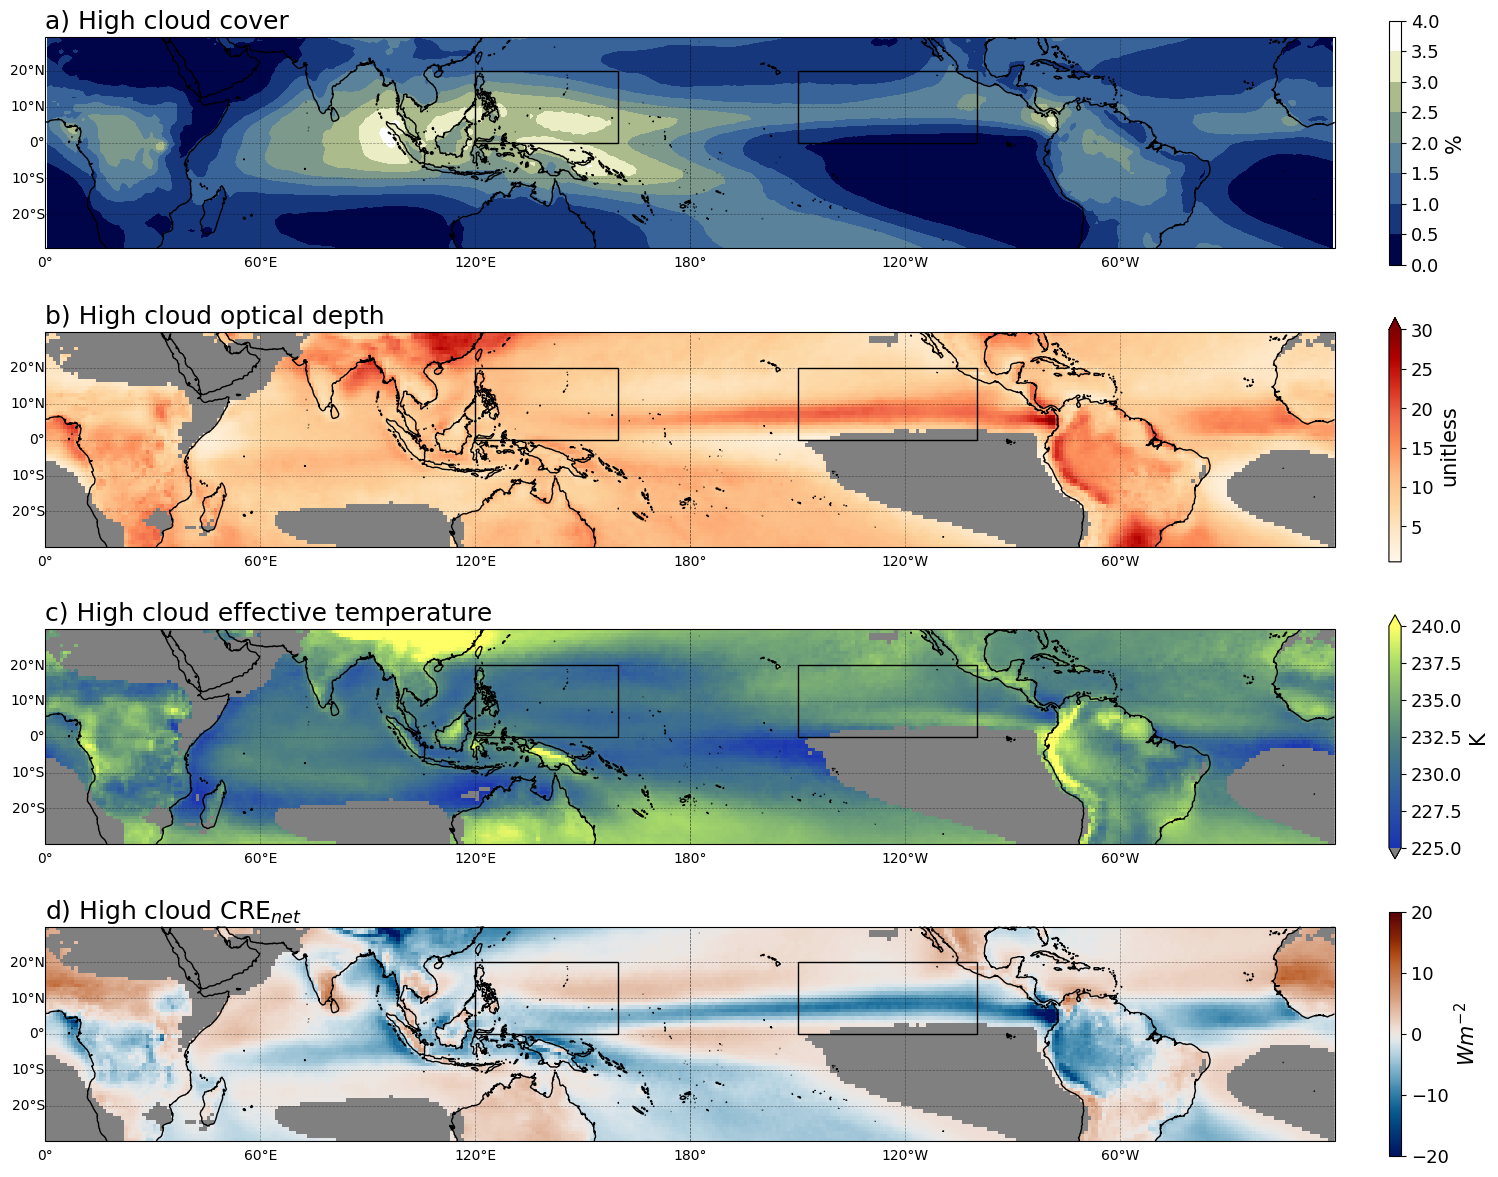

In [35]:
# Figure 1
n_rows = 4
n_cols = 1

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 3.*n_rows),
    sharex=True,
    subplot_kw={'projection': usemap_proj},
)

ax = axes.flatten()

# High cloud fraction
cf_map = tau_all.cldarea_cldtyp_mon.sel(press=[6,5,4]).mean(['press', 'opt', "time"])
plot0 = cf_map.plot.contourf(cmap=cm.davos, levels=9, vmin=0, vmax=4., transform = ccrs.PlateCarree(), add_colorbar=False, ax=ax[0], )
cbar = plt.colorbar(plot0, ax=ax[0], label= "%", fraction=0.009, pad=0.04, extend="both")

# High cloud optical depth
cmap = plt.get_cmap("OrRd").copy()
cmap.set_bad((0, 0, 0, 0))
norm = colors.Normalize(vmin=0.5, vmax=30., clip=False)
cmap.set_under('grey') 
odweight = tau_all.cldtau_cldtyp_mon.sel(press=[6,5,4]).weighted(tau_all.cldarea_cldtyp_mon.sel(press=[6,5,4])).mean(['press', 'opt', 'time'])
odweight_time = odweight #.mean(['time'])
odweight_masked = odweight_time.where(cf_map > 0.5, 0)
plot1 = odweight_masked.plot( norm=norm, cmap=cmap, transform = ccrs.PlateCarree(), add_colorbar=False, ax=ax[1], )
cbar = plt.colorbar(plot1, ax=ax[1], label="unitless",fraction=0.009, pad=0.04, extend="max")

# High cloud mean temperature
cmap = cm.imola.copy()
cmap.set_bad((0, 0, 0, 0))
norm = colors.Normalize(vmin=225, vmax=240, clip=False)
cmap.set_under('grey')
data = ctt_all.cldtemp_cldtyp_mon.sel(press=[6,5,4]).weighted(ctt_all.cldarea_cldtyp_mon.sel(press=[6,5,4])).mean(['press', 'opt'])
ctt_masked = data.mean(['time']).where(cf_map > 0.5, 0)
plot2 = ctt_masked.plot( transform = ccrs.PlateCarree(), add_colorbar=False, norm=norm, cmap=cmap, ax=ax[2])#
cbar = plt.colorbar(plot2, ax=ax[2], label= "K", fraction=0.009, pad=0.04, extend="both")

# High cloud NET CRE
k_lw = K("lw", alllw.sel(press=[6,5,4])) * alllw.cldarea_cldtyp_mon.sel(press=[6,5,4])
datalw = k_lw.sum(['press', 'opt',]).mean(['time'])

k_sw = K("sw", allsw.sel(press=[6,5,4])) * allsw.cldarea_cldtyp_mon.sel(press=[6,5,4])
datasw = k_sw.sum(['press', 'opt']).mean(['time'])

cmap = cm.vik.copy()
cmap.set_bad((0, 0, 0, 0))
norm = colors.Normalize(vmin=-20, vmax=20, clip=False)
cmap.set_over('grey')
netcre_tropics = datasw + datalw # netCRE(alllw.sel(press=[6,5,4]), allsw.sel(press=[6,5,4]), by_frac=True)
netcre_masked = netcre_tropics.where(cf_map > 0.5, 25)
plot5 = netcre_masked.plot(norm=norm, transform = ccrs.PlateCarree(), add_colorbar=False, cmap=cmap, ax=ax[3])#
cbar = plt.colorbar(plot5, ax=ax[3], label= r"$Wm^{-2}$", fraction=0.009, pad=0.04, extend="neither")

titles = ["a) High cloud cover", "b) High cloud optical depth", "c) High cloud effective temperature", "d) High cloud CRE$_{net}$"] #"d) LW CRE", "e) SW CRE",
for i in range(4):
    ax[i].coastlines(resolution='50m') #transparent
    gl = ax[i].gridlines(draw_labels=True, linewidth=0.5, alpha=0.4, color='k', linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = True
    gl.bottom_labels = True
    edgecolor="k"
    ax[i].add_patch(patches.Rectangle(xy=[120, 0], width=40, height=20, facecolor='none', edgecolor=edgecolor, transform=ccrs.PlateCarree()))
    ax[i].add_patch(patches.Rectangle(xy=[210, 0], width=50, height=20, facecolor='none', edgecolor=edgecolor, transform=ccrs.PlateCarree()))
    ax[i].set_title(titles[i], loc="left")

plt.tight_layout()    
    
plt.show()
#fig.savefig("results/maps.png")


## Figure 2

An area mean is a mean across lat, lon and time, a CTP-$\tau$ histogram.

In [36]:

cc_wp = tau_all.cldarea_cldtyp_mon.sel( lat=itcz, lon=wp)
cc_ep = tau_all.cldarea_cldtyp_mon.sel( lat=itcz, lon=ep) #shape (time, lat, lon, p, od)

In [37]:
# Shouldn't be detrended, is not an anomaly! 
cc_wp_areamean = area_mean_lat(cc_wp.mean("lon", skipna=True) )
cc_ep_areamean = area_mean_lat(cc_ep.mean("lon", skipna=True) ) 

In [39]:
cc_wp_areamean_anom = methods.anomaly(cc_wp_areamean)
cc_ep_areamean_anom = methods.anomaly(cc_ep_areamean)

In [40]:
def netCRE(lwds, swds, times=False, cc=None):
    """Returns an area-mean net Kernel 
    Parameters:
    ----------
    lwds: xr.Dataset
        LW dataset that includes clear and all-sky fluxes
    swds: xr.Dataset
        SW dataset that includes clear and all-sky fluxes
    times: bool
        If True, returns the kernel climatology (time-mean)
    """
    
    Klw = (lwds.toa_lw_clr_mon.mean("lon") - lwds.toa_lw_cldtyp_mon.mean("lon"))/100 #time, p, opt, lat
    Ksw = (swds.toa_sw_clr_mon.mean("lon") - swds.toa_sw_cldtyp_mon.mean("lon"))/100 #time, p, opt, lat

    Klw_areamean = area_mean_lat(Klw) #weighted mean by lat, shape (time, p, opt)
    Ksw_areamean = area_mean_lat(Ksw) #weighted mean by lat, shape (time, p, opt)
    
    if times:
        Knet = Klw_areamean.mean(['time']) + Ksw_areamean.mean(['time']) #shape (p, opt)
    else:
        Knet = Klw_areamean + Ksw_areamean #shape (time, p, opt)
    
    return Knet

In [41]:
K_ep = netCRE(alllw.sel(time=modistime, lat=itcz, lon=ep), allsw.sel(time=modistime, lat=itcz, lon=ep), times=True, cc=None)
K_wp = netCRE(alllw.sel(time=modistime, lat=itcz, lon=wp), allsw.sel(time=modistime, lat=itcz, lon=wp), times=True, cc=None)

<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_186/728433550.py:7: SyntaxWarning: invalid escape sequence '\p'
  axs[0,0].set_title("West Pacific \n \n a)cc, cc$^{hc}$ mean = (2.4 $\pm$ 0.6) %", wrap=True)
/tmp/ipykernel_186/728433550.py:15: SyntaxWarning: invalid escape sequence '\p'
  axs[0,1].set_title("East Pacific \n \n b)cc, cc$^{hc}$ mean = (1.5 $\pm$ 0.3) %", wrap=True)


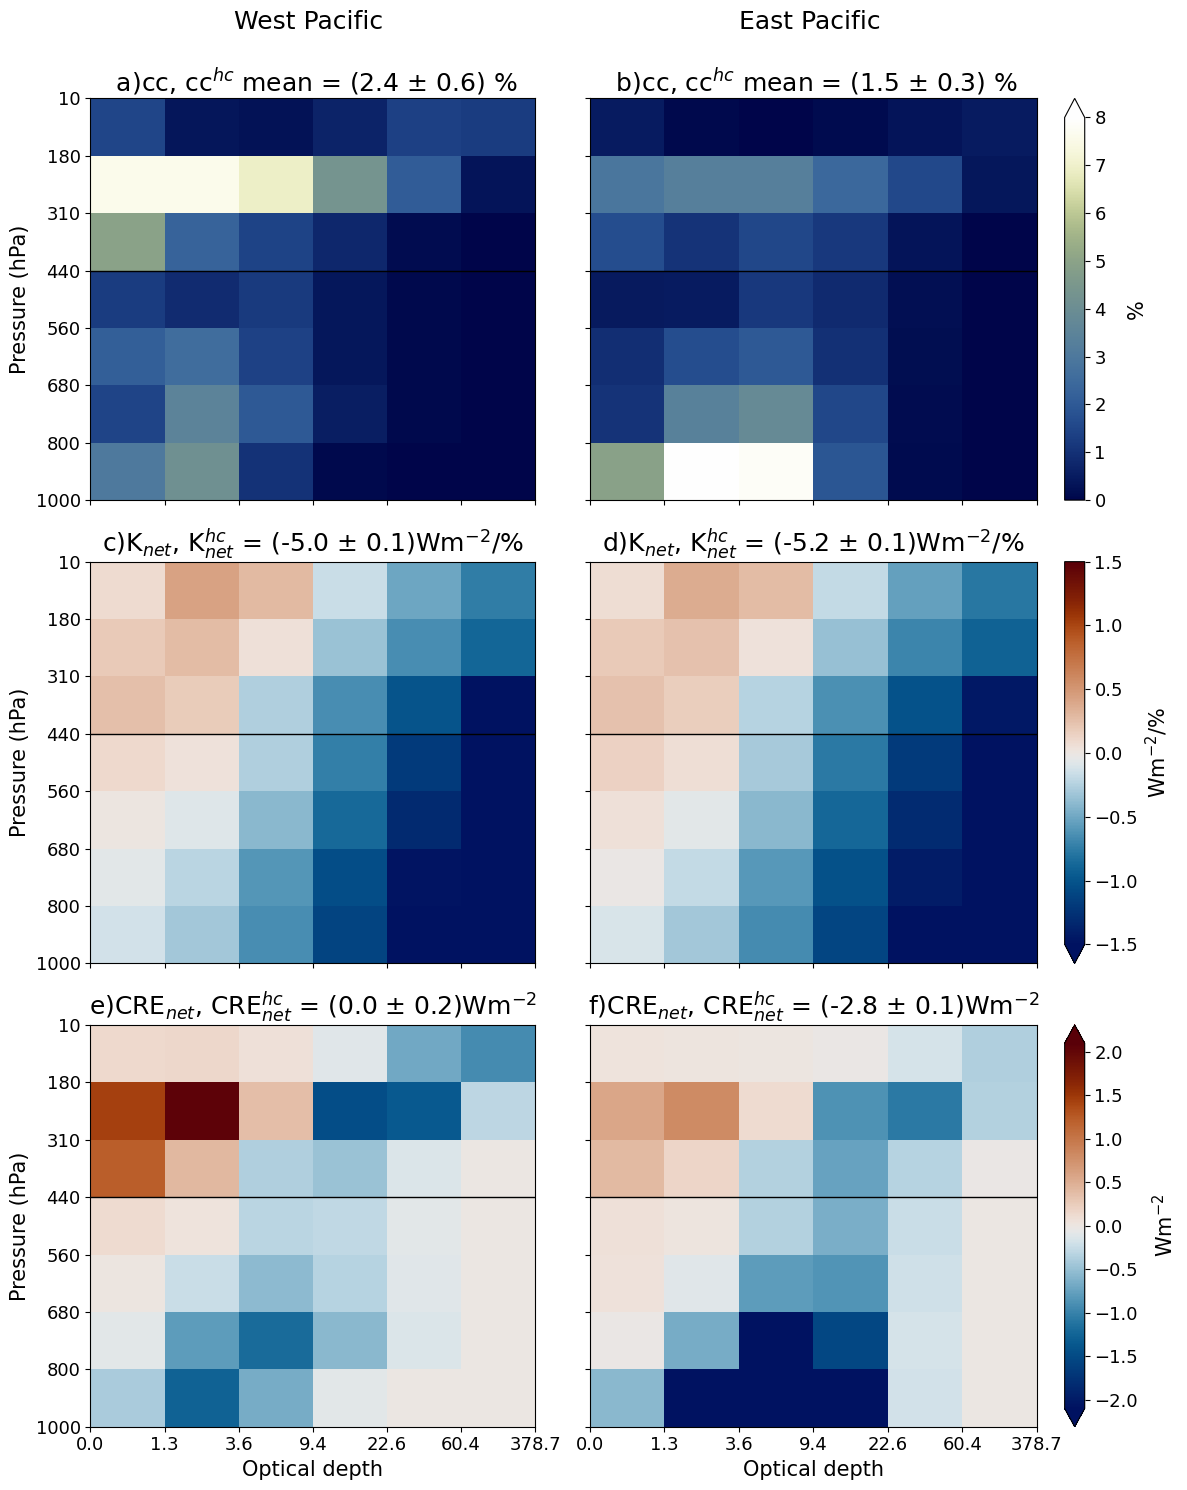

In [43]:
fig, axs = plt.subplots(3,2,figsize=(12.,15), sharex=True, sharey=True, gridspec_kw={"width_ratios": [0.9, 1.13]})

ccplotwp = cc_wp_areamean.mean(['time']).transpose()
ccplotwp.plot(cmap= cm.davos, vmin=0,vmax=8, add_colorbar=False,  ax=axs[0,0])
axs[0,0].set_xlabel("")
axs[0,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[0,0].set_title("West Pacific \n \n a)cc, cc$^{hc}$ mean = (2.4 $\pm$ 0.6) %", wrap=True)

ccplotep = cc_ep_areamean.mean(['time']).transpose()
p = ccplotep.plot(cmap= cm.davos, vmin=0,vmax=8, cbar_kwargs={'extend': 'max',}, ax=axs[0,1])
#ctp_tau(ccplotwp, axs[0,1], labels=False, arr=cc_wp.mean(['lat', 'lon', 'time']).transpose().data)
axs[0,1].set_xlabel("")
axs[0,1].set_ylabel("")
axs[0,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[0,1].set_title("East Pacific \n \n b)cc, cc$^{hc}$ mean = (1.5 $\pm$ 0.3) %", wrap=True)
p.colorbar.set_label("%", labelpad=15)

kPLOTwp = K_wp.transpose()
kPLOTwp.plot(cmap= cm.vik,  vmin=-1.50, vmax=1.50, add_colorbar=False,  ax=axs[1,0])
#ctp_tau(kPLOTep, axs[1,0], labels=False)
axs[1,0].set_xlabel("")
axs[1,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[1,0].set_title(r"c)K$_{net}$, K$_{net}^{hc}$ = (-5.0 $\pm$ 0.1)$\mathrm{Wm^{-2}/\%}$", wrap=True) 

kPLOTep = K_ep.transpose()
kPLOTep.plot(cmap= cm.vik,  vmin=-1.50, vmax=1.50, cbar_kwargs={'label': r"$\mathrm{Wm^{-2}/\%}$", 'extend': 'min'}, ax=axs[1,1])
#ctp_tau(kPLOTwp, axs[1,1], labels=False)
axs[1,1].set_xlabel("")
axs[1,1].set_ylabel("")
axs[1,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[1,1].set_title(r"d)K$_{net}$, K$_{net}^{hc}$ = (-5.2 $\pm$ 0.1)$\mathrm{Wm^{-2}/\%}$", wrap=True)

ccxK_wp = ccplotwp * kPLOTwp
ccxK_wp.plot(cmap= cm.vik,vmin=-2.10, vmax=2.10, add_colorbar=False, ax=axs[2,0])
axs[2,0].set_title(r"e)CRE$_{net}$, CRE$_{net}^{hc}$ = (0.0 $\pm$ 0.2)$\mathrm{Wm^{-2}}$", wrap=True)
axs[2,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

ccxK_ep = ccplotep * kPLOTep
q = ccxK_ep.plot(cmap= cm.vik,vmin=-2.10, vmax=2.10, cbar_kwargs={'extend': 'both'}, ax=axs[2,1])
axs[2,1].set_ylabel("")
axs[2,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[2,1].set_title(r"f)CRE$_{net}$, CRE$_{net}^{hc}$ = (-2.8 $\pm$ 0.1)$\mathrm{Wm^{-2}}$", wrap=True)
q.colorbar.set_label(r"$\mathrm{Wm^{-2}}$", labelpad=10)

 # ax.tick_params(axis='both', which='major', labelsize=13)
axs[0,0].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[1,0].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[2,0].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[0,0].set_ylabel("Pressure (hPa)")
axs[1,0].set_ylabel("Pressure (hPa)")
axs[2,0].set_ylabel("Pressure (hPa)")

axs[2,0].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,1].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,0].set_xlabel("Optical depth")
axs[2,1].set_xlabel("Optical depth")


plt.tight_layout()
#plt.savefig("results/climatology_cc_K.png")

Calculating high cloud integrated mean values (shown on top)

In [84]:
#Mean High cloud 
print(ccplotwp.sel(press=[4,5,6]).mean(["press", "opt"]).item(), kPLOTwp.sel(press=[4,5,6]).mean(["press", "opt"]).item(), (ccxK_wp).sel(press=[4,5,6]).mean(["press", "opt"]).item())
print(ccplotep.sel(press=[4,5,6]).mean(["press", "opt"]).item(), kPLOTep.sel(press=[4,5,6]).mean(["press", "opt"]).item(), (ccxK_ep).sel(press=[4,5,6]).mean(["press", "opt"]).item())

2.430851936340332 -0.2752244174480438 -0.0008861488895490766
1.169127345085144 -0.28923872113227844 -0.12010268121957779


In [45]:
#Errors
print((ccplotwp.sel(press=[4,5,6]).std(["press", "opt"])/ np.sqrt(18)).values.item(), (kPLOTwp.sel(press=[4,5,6]).std(["press", "opt"])/ np.sqrt(18)).values.item(), (ccxK_wp.sel(press=[4,5,6]).std(["press", "opt"])/ np.sqrt(18)).values.item())

print((ccplotep.sel(press=[4,5,6]).std(["press", "opt"])/ np.sqrt(18)).values.item(), (kPLOTep.sel(press=[4,5,6]).std(["press", "opt"])/ np.sqrt(18)).values.item(), (ccxK_ep.sel(press=[4,5,6]).std(["press", "opt"])/ np.sqrt(18)).values.item())

0.603529271292883 0.12431201729128592 0.20824801400976203
0.2600003119326324 0.12279092347957826 0.10977990334080044


# Section 2: Influence of Ts and AOD on cloud properties

In [46]:
# Thanks https://gist.github.com/rabernat/1ea82bb067c3273a6166d1b1f77d490f
def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xa.polyval(da[dim], p.polyfit_coefficients)
    return da - fit

def detrend(da, dims, deg=1):
    # detrend along multiple dimensions
    # only valid for linear detrending (deg=1)
    da_detrended = da
    for dim in dims:
        da_detrended = detrend_dim(da_detrended, dim, deg=deg)
    return da_detrended

## Figure 3: Sensitivities of cloud cover 

In [47]:
#Cloud cover anomaly WP
area_anom_wp = cc_wp_areamean.groupby("time.month") - cc_wp_areamean.groupby("time.month").mean("time")

In [48]:
#Cloud cover anomaly EP
area_anom_ep = cc_ep_areamean.groupby("time.month") - cc_ep_areamean.groupby("time.month").mean("time")

In [49]:
def significant_bins(df,i, threshold, ax,  vmin, vmax, cbar=False, values=None, units="%/K"):
    """Plots hatched bins if pvalue>threshold.
    df: xa.Dataset
        Must include p_values data if values = None
    i: int
        indep variable
    threshold: float
        threshold for p values
    title: str
        title of the plot
    vmin: float
    vmax: float
    values: np.array
        p_values
    units: str
        units for the plot"""
    
    press_ticks = ['1000','800','680','560','440','310','180','10']
    opt_ticks = ['0.0', '1.3', '3.6', '9.4', '22.6', '60.4', '378.7']
    
    if values is None:
        values = df.sel(indep=i).p_values   
    
    # Calcular máscara de significancia
    significant = values < threshold

    if cbar:
        plott = df.sel(indep=i).slopes.plot(
            cmap=cmap, vmin=vmin, vmax=vmax, ax=ax,
            cbar_kwargs={'label': units, 'extend': 'both'}
        )
    else:
        plott = df.sel(indep=i).slopes.plot(
            cmap=cmap, vmin=vmin, vmax=vmax, ax=ax,
            add_colorbar=False
        )

    # Hatch non significant bins
    for i in range(significant.shape[0]):     # rows (Y = 7)
        for j in range(significant.shape[1]): # cols (X = 6)
            if not significant[i, j]:
                rect = plt.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    fill=False,
                    hatch='//',
                    edgecolor='gray',
                    linewidth=0
                )
                ax.add_patch(rect)

In [50]:
#Standardise independent variables
ep_std = [ ( detrend_glob/detrend_glob.std() ), (detrend_ep_s/detrend_ep_s.std()), (detrend_ep_aod/detrend_ep_aod.std()) ]
wp_std = [ ( detrend_glob/detrend_glob.std() ), (detrend_wp_s/detrend_wp_s.std()), (detrend_wp_aod/detrend_wp_aod.std()) ]

In [51]:
#Compute MLR as eq. 
cc_ml_wp = methods.deriv(area_anom_wp, wp_std)

In [52]:
#Compute MLR as eq. 
cc_ml_ep = methods.deriv(area_anom_ep, ep_std) 

In [53]:
# Calculate intercepts
X = np.column_stack([  detrend_glob/detrend_glob.std() , detrend_wp_s/detrend_wp_s.std(), detrend_wp_aod/detrend_wp_aod.std() ])

for p in range(7):
    for opt in range(6):    
        lineer = LinearRegression().fit(X, area_anom_wp[opt,p,:].values)
        print(lineer.intercept_)


-9.661720611859585e-08
-1.0142403220086578e-07
2.685814151008203e-08
2.6259165668254014e-09
-5.465036347008847e-10
-3.922196187586567e-12
-2.908129839633479e-08
-4.9029626915669995e-08
3.4609149059376514e-08
-1.1431233421824332e-08
4.44255888861021e-09
-1.4459865809470358e-10
-1.8265939669362493e-08
-9.661720660276179e-08
-6.489215343241689e-09
-2.394400293175626e-08
-1.3012228798946246e-09
-1.0972615315451118e-11
3.6051180029351494e-10
8.411945043696314e-10
-2.884095806444695e-09
-9.193055120593265e-09
2.5123177353839154e-09
-1.4293736200905844e-10
-9.22910631464069e-08
-5.239440560432925e-08
1.6823890764417875e-09
-7.210239344760121e-09
-3.0493303748883384e-09
-8.355615870185265e-11
-2.6918226754330006e-07
-6.248874130518146e-08
1.2209338451099888e-07
-5.575918432993695e-08
1.6823891487974937e-08
8.892628455271637e-09
2.0789522997334728e-08
-3.424863709700859e-09
6.879769919940145e-09
7.210238110059436e-10
2.7639250387483385e-08
9.613652268322573e-09


Figure 3

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_186/2040043406.py:8: SyntaxWarning: invalid escape sequence '\m'
  axs[0,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title="West Pacific \n \n a)$\mathrm{\Theta_{T_{global}}}$",)
/tmp/ipykernel_186/2040043406.py:28: SyntaxWarning: invalid escape sequence '\m'
  axs[0,1].set(xlabel=None, ylabel=None, title="East Pacific \n \n b)$\mathrm{\Theta_{T_{global}}}$",)


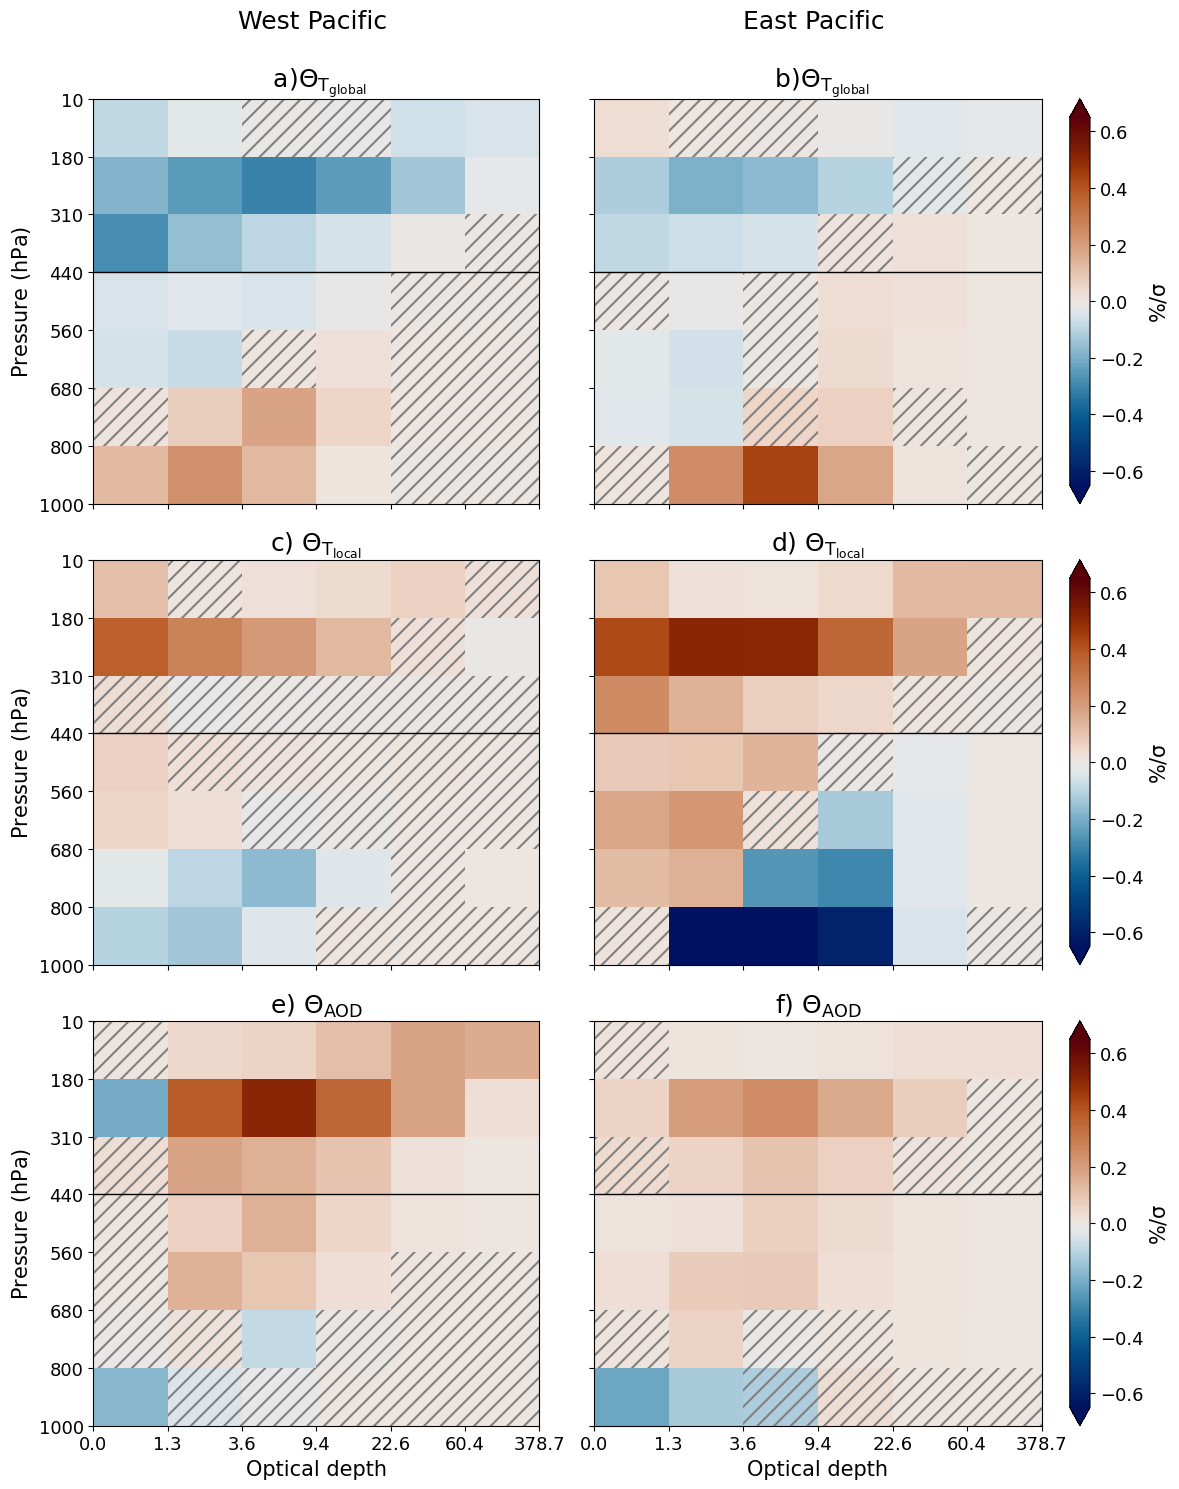

In [55]:
#Fig 3
cmap=cm.vik
#fig, axs = plt.subplots(3,2,figsize=(10,15), sharex=True, sharey=True, gridspec_kw={"width_ratios": [0.85,1]})
fig, axs = plt.subplots(3,2,figsize=(12.,15), sharex=True, sharey=True, gridspec_kw={"width_ratios": [0.9, 1.13]})
#WP
var=0
significant_bins(cc_ml_wp, var, 0.05, ax=axs[0,0], vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_wp, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[0,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title="West Pacific \n \n a)$\mathrm{\Theta_{T_{global}}}$",)
axs[0,0].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[0,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=1
significant_bins(cc_ml_wp, var, 0.05, ax=axs[1,0], vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_wp, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[1,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title=r"c) $\mathrm{\Theta_{T_{local}}}$", )
axs[1,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[1,0].set_yticks(np.arange(-0.5,7.5,1), pressure)

var=2
significant_bins(cc_ml_wp, var, 0.05, ax=axs[2,0],vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_wp, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[2,0].set(xlabel="Optical depth", ylabel=r"Pressure $\mathrm{(hPa)}$", title=r"e) $\mathrm{\Theta_{AOD}}$", )
axs[2,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[2,0].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,0].set_yticks(np.arange(-0.5,7.5,1), pressure)

#EP
var=0
significant_bins(cc_ml_ep, var, 0.05, ax=axs[0,1], cbar=True,vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_ep, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[0,1].set(xlabel=None, ylabel=None, title="East Pacific \n \n b)$\mathrm{\Theta_{T_{global}}}$",)
axs[0,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=1
significant_bins(cc_ml_ep, var, 0.05, ax=axs[1,1],cbar=True, vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_ep, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[1,1].set( xlabel=None,ylabel=None, title=r"d) $\mathrm{\Theta_{T_{local}}}$", )
axs[1,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=2
significant_bins(cc_ml_ep, var, 0.05, ax=axs[2,1],cbar=True, vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_ep, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[2,1].set(xlabel="Optical depth", ylabel=None, title=r"f) $\mathrm{\Theta_{AOD}}$", )
axs[2,1].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

plt.tight_layout()

#plt.savefig("results/ccsens_detrend_std.png")

### Associated SI

fIGURE S4: Comparing R2 adjusted using simple linear regression vs Multi Linear regression

<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_186/2543971492.py:3: SyntaxWarning: invalid escape sequence '\T'
  titles = ["Linear regress. $\Theta_{T_{global}}$", "Linear regress. $\Theta_{T_{local}}$","Linear regress. $\Theta_{AOD}$", "Multi-linear regress.",]
/tmp/ipykernel_186/2543971492.py:3: SyntaxWarning: invalid escape sequence '\T'
  titles = ["Linear regress. $\Theta_{T_{global}}$", "Linear regress. $\Theta_{T_{local}}$","Linear regress. $\Theta_{AOD}$", "Multi-linear regress.",]
/tmp/ipykernel_186/2543971492.py:3: SyntaxWarning: invalid escape sequence '\T'
  titles = ["Linear regress. $\Theta_{T_{global}}$", "Linear regress. $\Theta_{T_{local}}$","Linear regress. $\Theta_{AOD}$", "Multi-linear regress.",]


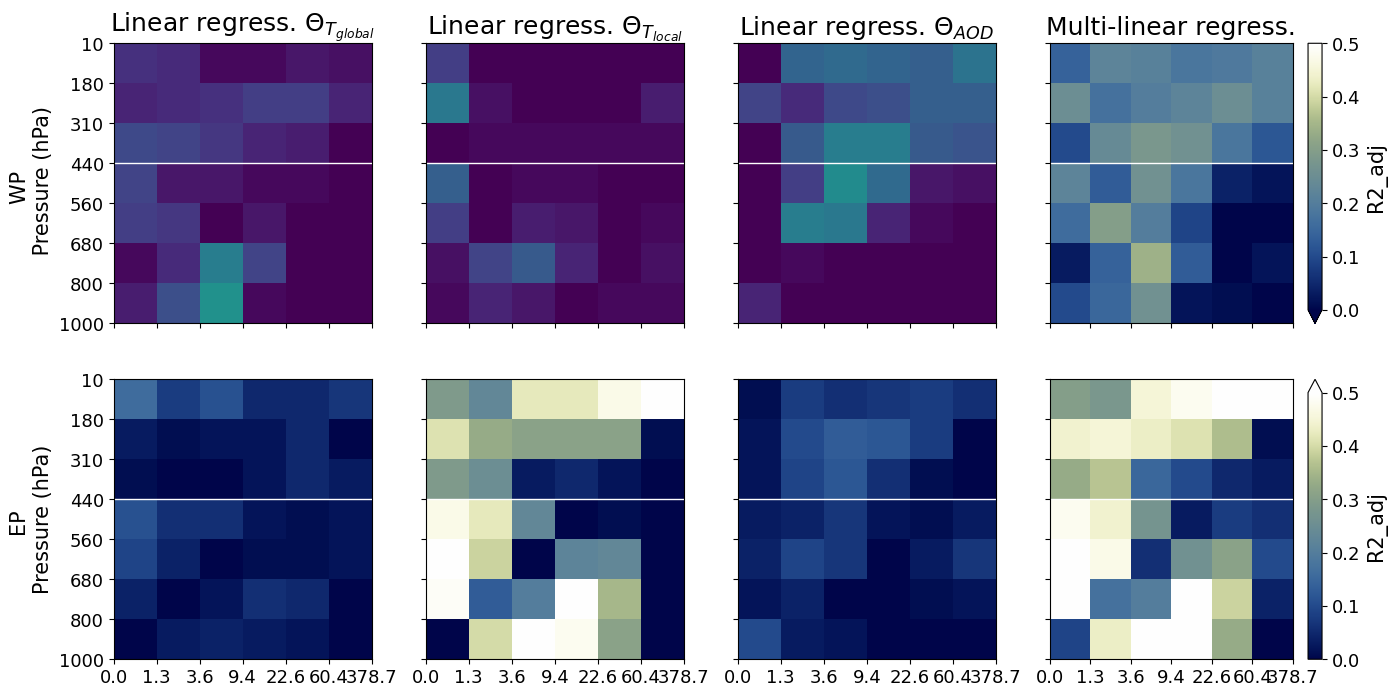

In [67]:
fig, axs = plt.subplots(2,4,figsize=(16,8), sharey=True,sharex=True, 
                        gridspec_kw={"width_ratios": [0.85, 0.85, 0.85, 1]})
titles = ["Linear regress. $\Theta_{T_{global}}$", "Linear regress. $\Theta_{T_{local}}$","Linear regress. $\Theta_{AOD}$", "Multi-linear regress.",]

#wP
for i in range(3):
    methods.deriv(area_anom_wp, [wp_per[i]]).R2_adj.plot(ax=axs[0, i], vmin=0, vmax=0.5, add_colorbar=False)
    axs[0, i].axhline(y=3.5, xmin=0, xmax=6, c="w", lw=1.)
    axs[0, i].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
    axs[0, i].set_yticks(np.arange(-0.5,7.5,1), pressure)
    axs[0, i].set(xlabel=None, ylabel=None, title=titles[i])

axs[0, 0].set(ylabel="WP \n Pressure (hPa)")

cc_ml_wp_per.R2_adj.plot(ax=axs[0, 3], vmin=0, vmax=0.5, cmap=cm.davos, add_colorbar=True)
axs[0, 3].axhline(y=3.5, xmin=0, xmax=6, c="w", lw=1.)
axs[0, 3].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[0, 3].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[0, 3].set(xlabel=None, ylabel=None, title=titles[3])

#EP
for i in range(3):
    methods.deriv(area_anom_ep, [ep_per[i]]).R2_adj.plot(ax=axs[1, i], vmin=0, vmax=0.5, cmap=cm.davos, add_colorbar=False)
    axs[1, i].axhline(y=3.5, xmin=0, xmax=6, c="w", lw=1.)
    axs[1, i].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
    axs[1, i].set_yticks(np.arange(-0.5,7.5,1), pressure)
    axs[1, i].set(xlabel=None, ylabel=None, )

axs[1, 0].set(ylabel="EP \nPressure (hPa)")

cc_ml_ep_per.R2_adj.plot(ax=axs[1, 3], vmin=0, vmax=0.5, cmap=cm.davos, add_colorbar=True)
axs[1, 3].axhline(y=3.5, xmin=0, xmax=6, c="w", lw=1.)
axs[1, 3].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[1, 3].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[1, 3].set(xlabel=None, ylabel=None, )

#plt.savefig("R2_adj_cc.jpg")

Same as Figure 3 but independent variables not standardised

In [57]:
# Indep
ep_per = [  detrend_glob, detrend_ep_s, detrend_ep_aod]
wp_per = [  detrend_glob, detrend_wp_s, detrend_wp_aod]

In [58]:
cc_ml_ep_per = methods.deriv(area_anom_ep, ep_per) 
cc_ml_wp_per = methods.deriv(area_anom_wp, wp_per)

## Figure 4: Sensitivities of net CRE

Coefficient from multi-linear regression with 3 variables

In [69]:
def radiative_anomaly(lwds, swds, wave=None):
    """By definition, it's the kernel timed by cc anomaly"""
    
    #cc is the same for each wave, mean over lon to avoid missing data
    lw_cc = lwds["cldarea_cldtyp_mon"].mean("lon") #time, p, opt, lat
    # compute monthly anomaly for cc
    d_cc = methods.anomaly(lw_cc)
    
    #Kernels lat = clr mean lon - all mean lon /100
    K_lw = (lwds.toa_lw_clr_mon.mean("lon") - lwds.toa_lw_cldtyp_mon.mean("lon"))/100 #time, p, opt, lat
    K_sw = (swds.toa_sw_clr_mon.mean("lon") - swds.toa_sw_cldtyp_mon.mean("lon"))/100 #time, p, opt, lat
    #print(K_lw.isnull().sum() ,K_sw.isnull().sum()  ) 18~21 k nans
    
    #Radiative anomaly
    rad_lw = K_lw*d_cc #time, p, opt, lat
    rad_sw = K_sw*d_cc #time, p, opt, lat
    
    #Area mean
    lats_weights = genweights(lwds["lat"], lat_name="lat") #transform lats to radian
    weights = lats_weights.broadcast_like(rad_lw) #weights have same shape as da
    
    rad_lw_areamean = (rad_lw * weights).sum("lat", skipna=True)/ weights_sum #time, p, opt
    rad_sw_areamean = (rad_sw * weights).sum("lat", skipna=True)/ weights_sum #time, p, opt

    if wave=="sw":
        return rad_sw_areamean
    elif wave=="lw":       
        return rad_lw_areamean
    else:
        return rad_lw_areamean + rad_sw_areamean

In [70]:
net_wp = radiative_anomaly(alllw.sel( lat=itcz, lon=wp), allsw.sel( lat=itcz, lon=wp))
net_ep = radiative_anomaly(alllw.sel( lat=itcz, lon=ep), allsw.sel( lat=itcz, lon=ep))

NameError: name 'weights_sum' is not defined

In [71]:
net_wp = detrend(net_wp, ["time", ]) 
net_ep = detrend(net_ep, ["time", ])

NameError: name 'net_wp' is not defined

In [73]:
#MLR 
ml3_ep = methods.deriv(net_ep, ep_std) 
ml3_wp = methods.deriv(net_wp, wp_std)

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_136/2248793955.py:9: SyntaxWarning: invalid escape sequence '\m'
  axs[0,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title="West Pacific \n \n a) $\mathrm{\Theta_{T_{global}}}$, $\Theta^{hc}_{T_{global}} = 0.06 \pm 0.04$",)
/tmp/ipykernel_136/2248793955.py:29: SyntaxWarning: invalid escape sequence '\m'
  axs[0,1].set(xlabel=None, ylabel=None, title="East Pacific \n \n b) $\mathrm{\Theta_{T_{global}}}$, ${\Theta^{hc}}_{T_{global}} = 0.03 \pm 0.03$",)


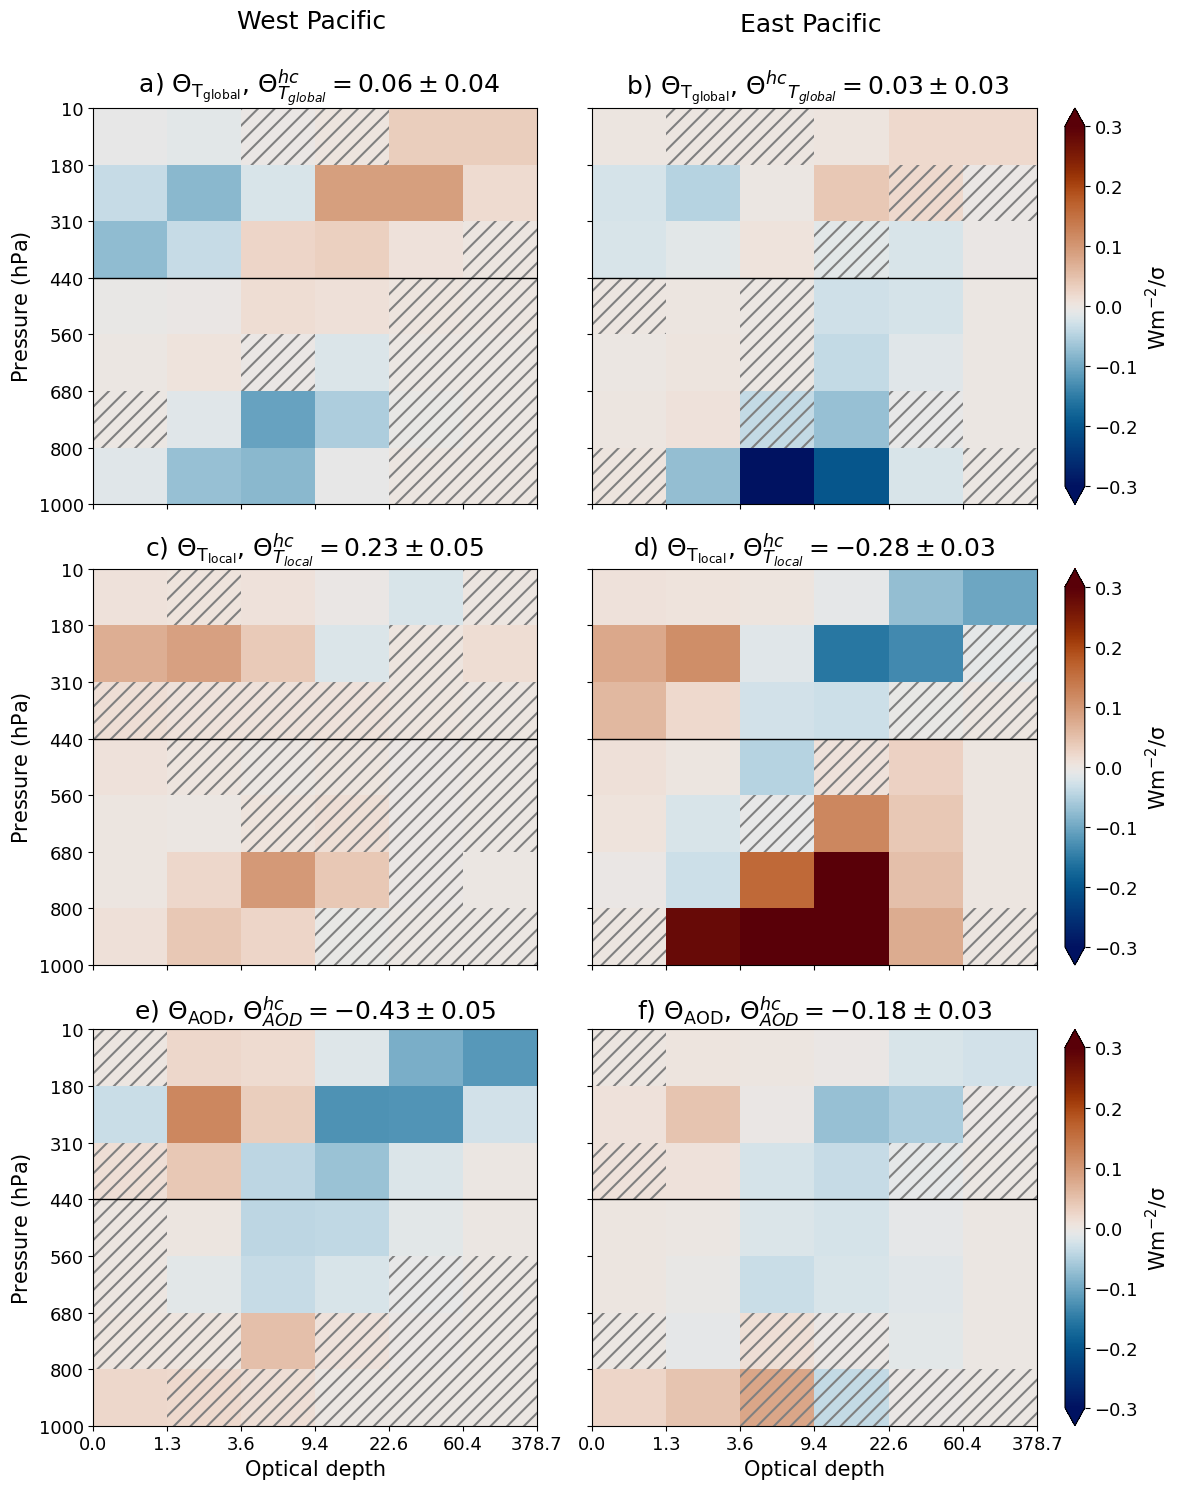

In [118]:
#Figure 4
mn = 0.3

fig, axs = plt.subplots(3,2,figsize=(12.,15), sharex=True, sharey=True, gridspec_kw={"width_ratios": [0.9, 1.13]})
#WP
var=0
significant_bins(ml3_wp, var, 0.05, ax=axs[0,0], vmin=-mn, vmax=mn, values=methods.new_pvals(cc_ml_wp, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[0,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title="West Pacific \n \n a) $\mathrm{\Theta_{T_{global}}}$, $\Theta^{hc}_{T_{global}} = 0.06 \pm 0.04$",)
axs[0,0].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[0,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=1
significant_bins(ml3_wp, var, 0.05, ax=axs[1,0], vmin=-mn, vmax=mn, values=methods.new_pvals(cc_ml_wp, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[1,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title=r"c) $\mathrm{\Theta_{T_{local}}}$, $\Theta^{hc}_{T_{local}} = 0.23 \pm 0.05$", )
axs[1,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[1,0].set_yticks(np.arange(-0.5,7.5,1), pressure)

var=2
significant_bins(ml3_wp, var, 0.05, ax=axs[2,0],vmin=-mn, vmax=mn, values=methods.new_pvals(cc_ml_wp, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[2,0].set(xlabel="Optical depth", ylabel=r"Pressure $\mathrm{(hPa)}$", title=r"e) $\mathrm{\Theta_{AOD}}$, $\Theta^{hc}_{AOD} = -0.43 \pm 0.05$", )
axs[2,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[2,0].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,0].set_yticks(np.arange(-0.5,7.5,1), pressure)

#EP
var=0
significant_bins(ml3_ep, var, 0.05, ax=axs[0,1], cbar=True,vmin=-mn, vmax=mn, values=methods.new_pvals(cc_ml_ep, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[0,1].set(xlabel=None, ylabel=None, title="East Pacific \n \n b) $\mathrm{\Theta_{T_{global}}}$, ${\Theta^{hc}}_{T_{global}} = 0.03 \pm 0.03$",)
axs[0,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=1
significant_bins(ml3_ep, var, 0.05, ax=axs[1,1],cbar=True, vmin=-mn, vmax=mn, values=methods.new_pvals(cc_ml_ep, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[1,1].set( xlabel=None,ylabel=None, title=r"d) $\mathrm{\Theta_{T_{local}}}$, $\Theta^{hc}_{T_{local}} = -0.28 \pm 0.03$", )
axs[1,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=2
significant_bins(ml3_ep, var, 0.05, ax=axs[2,1],cbar=True, vmin=-mn, vmax=mn, values=methods.new_pvals(cc_ml_ep, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[2,1].set(xlabel="Optical depth", ylabel=None, title=r"f) $\mathrm{\Theta_{AOD}}$, $\Theta^{hc}_{AOD} = -0.18 \pm 0.03$", )
axs[2,1].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

plt.tight_layout()

plt.savefig("results/okcresens_std.png")

Computing high cloud integrated values (shown on top of each figure)

In [ ]:
total_hc(ml3_ep, var=0) 

In [ ]:
total_hc(ml3_ep, var=1) 

In [ ]:
total_hc(ml3_ep, var=2)

In [ ]:
total_hc(ml3_wp, var=0)

In [ ]:
total_hc(ml3_wp, var=1)

In [ ]:
total_hc(ml3_wp, var=2)

### Associated SI

Same as Figure 2 but Temperatures in K 

In [74]:
ml3_ep_wm2 = methods.deriv(net_ep, ep_per) 
ml3_wp_wm2 = methods.deriv(net_wp, wp_per)

In [ ]:
#Fig 3
#fig, axs = plt.subplots(3,2,figsize=(10,15), sharex=True, sharey=True, gridspec_kw={"width_ratios": [0.85,1]})
fig, axs = plt.subplots(3,2,figsize=(12.,15), sharex=True, sharey=True, gridspec_kw={"width_ratios": [0.9, 1.13]})
#WP
var=0
significant_bins(ml3_wp_merra2, var, 0.05, ax=axs[0,0], vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_wp, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[0,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title="West Pacific \n \n a)$\mathrm{\Theta_{T_{global}}}$",)
axs[0,0].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[0,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=1
significant_bins(ml3_wp_merra2, var, 0.05, ax=axs[1,0], vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_wp, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[1,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title=r"c) $\mathrm{\Theta_{T_{local}}}$", )
axs[1,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[1,0].set_yticks(np.arange(-0.5,7.5,1), pressure)

var=2
significant_bins(ml3_wp_merra2, var, 0.05, ax=axs[2,0],vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_wp, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[2,0].set(xlabel="Optical depth", ylabel=r"Pressure $\mathrm{(hPa)}$", title=r"e) $\mathrm{\Theta_{AOD}}$", )
axs[2,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[2,0].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,0].set_yticks(np.arange(-0.5,7.5,1), pressure)

#EP
var=0
significant_bins(ml3_ep_merra2, var, 0.05, ax=axs[0,1], cbar=True,vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_ep, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[0,1].set(xlabel=None, ylabel=None, title="East Pacific \n \n b)$\mathrm{\Theta_{T_{global}}}$",)
axs[0,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=1
significant_bins(ml3_ep_merra2, var, 0.05, ax=axs[1,1],cbar=True, vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_ep, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[1,1].set( xlabel=None,ylabel=None, title=r"d) $\mathrm{\Theta_{T_{local}}}$", )
axs[1,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=2
significant_bins(ml3_ep_merra2, var, 0.05, ax=axs[2,1],cbar=True, vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_ep, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[2,1].set(xlabel="Optical depth", ylabel=None, title=r"f) $\mathrm{\Theta_{AOD}}$", )
axs[2,1].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

plt.tight_layout()

plt.savefig("results/ccsens_detrend_.png")

R2 adjusted values

In [ ]:
fig, axs = plt.subplots(3,4,figsize=(17,12), sharey=True,sharex=True, gridspec_kw={"width_ratios": [0.85, 0.85, 0.85, 1]})
titles = ["Linear regress. $\Theta_{T_{global}}$", "Linear regress. $\Theta_{T_{local}}$", "Linear regress. $\Theta_{AOD}$", "Multi-linear regress.",]

#wP
for i in range(3):
    methods.deriv(net_wp, [wp_per[i]]).R2_adj.plot(ax=axs[0, i], vmin=0, vmax=0.5, add_colorbar=False)
    axs[0, i].axhline(y=3.5, xmin=0, xmax=6, c="w", lw=1.)
    axs[0, i].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
    axs[0, i].set_yticks(np.arange(-0.5,7.5,1), pressure)
    axs[0, i].set(xlabel=None, ylabel=None, title=titles[i])

axs[0, 0].set(ylabel="WP \n Pressure (hPa)")

ml3_wp_wm2.R2_adj.plot(ax=axs[0, 3], vmin=0, vmax=0.5, add_colorbar=True)
axs[0, 3].axhline(y=3.5, xmin=0, xmax=6, c="w", lw=1.)
axs[0, 3].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[0, 3].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[0, 3].set(xlabel=None, ylabel=None, title=titles[3])

#EP
for i in range(3):
    methods.deriv(net_ep, [ep_per[i]]).R2_adj.plot(ax=axs[1, i], vmin=0, vmax=0.5, add_colorbar=False)
    axs[1, i].axhline(y=3.5, xmin=0, xmax=6, c="w", lw=1.)
    axs[1, i].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
    axs[1, i].set_yticks(np.arange(-0.5,7.5,1), pressure)
    axs[1, i].set(xlabel=None, ylabel=None, )

axs[1, 0].set(ylabel="EP \nPressure (hPa)")

ml3_ep_wm2.R2_adj.plot(ax=axs[1, 3], vmin=0, vmax=0.5, add_colorbar=True)
axs[1, 3].axhline(y=3.5, xmin=0, xmax=6, c="w", lw=1.)
axs[1, 3].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[1, 3].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[1, 3].set(xlabel=None, ylabel=None, )

#CP
for i in range(3):
    methods.deriv(net_cp, [cp_per[i]]).R2_adj.plot(ax=axs[2, i], vmin=0, vmax=0.5, add_colorbar=False)
    axs[2, i].axhline(y=3.5, xmin=0, xmax=6, c="w", lw=1.)
    axs[2, i].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
    axs[2, i].set_yticks(np.arange(-0.5,7.5,1), pressure)
    axs[2, i].set(xlabel=None, ylabel=None, )

axs[2, 0].set(ylabel="CP \n Pressure (hPa)")

ml3_cp_wm2.R2_adj.plot(ax=axs[2, 3], vmin=0, vmax=0.5, add_colorbar=True)
axs[2, 3].axhline(y=3.5, xmin=0, xmax=6, c="w", lw=1.)
axs[2, 3].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2, 3].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[2, 3].set(xlabel=None, ylabel=None, )

plt.savefig("results/R2adj_cre.png")

# Section 3: Decomposition

In [82]:
def total_hc(dsregress, var=0):
    #tcrit = t.ppf(0.975, df=Neff(dsregress.res) )
    total = dsregress.sel(press=[4,5,6], indep=var).slopes.sum(["press", "opt"]).data.item()
    ci = np.sqrt( ( (dsregress.sel(press=[4,5,6], indep=var).stderr)*(dsregress.sel(press=[4,5,6], indep=var).stderr) ).sum(["press", "opt"]).data).item()
    return total, ci

In [77]:
def decompos_hc(wave, allradds, dates, exog, var=0, p_adj=True, lag=1):
    """Decomposes a variable into amount, altitude and optical depth. 
    wave:str
        sw, lw or net
    allrads: ds
        Datasets
    dates: slice
        datse slice
    exog: list of np.array"""

    tcrit = t.ppf(0.975, df=allradds[0].time.shape[0] - len(exog))

    # Retrieves cloud cover, mean across lon
    cc = allradds[0].cldarea_cldtyp_mon.sel(time=dates).mean("lon")

    lats = cc["lat"] #.values #get lat values, same for all ds because it'sa a fixed grid
    weights = genweights(lats)
    ws = np.sum(weights.values)

    # Calculates kernels
    if wave == "net":
        K_cc = methods.K( # means lon
            "sw", allradds[0].sel(time=dates)) + methods.K("lw", allradds[1].sel(time=dates))
    else:
        K_cc = methods.K(wave, allradds[0].sel(time=dates),)
    
    cc_anom = methods.anomaly(cc)  #Cloud cover  (time, lat, lon, p, opt)
    cTot = cc.sum(["press", "opt"])  #Cloud cover total (time, lat, lon)
    cTot_anom = cc_anom.sum(["press", "opt"]) #Cloud cover total anomaly (time, lat, lon)
    cc_ast = cc_anom - (cc / cTot) * cTot_anom #Weighted cc (time, lat, lon, p, opt)

    #Amount
    K_0_hc = (((cc / cTot)) * K_cc).sum(["opt", "press"]) #K0 climatology (time, lat, lon)
    Ramt_anom = K_0_hc * cTot_anom #Amount radiative anomaly (time, lat, lon)
    Ramt_anom_mean = Ramt_anom.weighted(weights).mean("lat").data #Ramt(time) 
    feed_amount = sm.OLS(endog=Ramt_anom_mean, exog=exog).fit() #Regression with all independent variables
    
    if p_adj:
        tcrit = t.ppf(0.975, df=Neff(feed_amount.resid, lag=1))
    f_amt = feed_amount.params[var]
    ci_amt = tcrit * feed_amount.bse[var]
    
    #Altitude
    ct_Tot = (cc / cTot).sum("press")
    Kp = K_cc * ct_Tot.sum("opt")
    K_prima_p = (Kp * ct_Tot).sum("opt")
    almost_R = K_prima_p * cc_ast.sum("opt")
    R_altitude = almost_R.sum("press")
    R_altitude_mean = R_altitude.weighted(weights).mean("lat") #time, p, opt
    feed_alt = sm.OLS(endog=R_altitude_mean.data, exog=exog).fit() #exog= N_exog, time 
    if p_adj:
        tcrit = t.ppf(0.975, df=Neff(feed_alt.resid, lag=1))
    f_alt = feed_alt.params[var]
    ci_alt = tcrit * feed_alt.bse[var]

    #Optical depth
    cp_Tot = (cc / cTot).sum("opt")
    Ktau = K_cc * cp_Tot.sum("press")
    K_prima_tau = (Ktau * cp_Tot).sum("press")
    casi_R = K_prima_tau * cc_ast.sum("press")
    R_od = casi_R.sum("opt")
    #weights = genweights(lats)
    #R_od_mean = (R_od* weights).sum("lat", skipna=True) / ws
    R_od_mean = R_od.weighted(weights).mean("lat")
    feed_od = sm.OLS(endog=R_od_mean.data, exog=exog).fit() 
    if p_adj:
        tcrit = t.ppf(0.975, df=Neff(feed_od.resid, lag=1))
    f_tau = feed_od.params[var]
    ci_tau = tcrit * feed_od.bse[var]

    #Residual
    k_R = K_cc - K_prima_p - K_prima_tau
    R_res = (k_R * cc_ast).sum(["press", "opt"])
    #weights = genweights(lats)
    #R_res_mean = (R_res* weights).sum("lat", skipna=True) / ws
    R_res_mean = R_res.weighted(weights).mean("lat")
    feed_res = sm.OLS(endog=R_res_mean.data, exog=exog).fit() 

    if p_adj:
        tcrit = t.ppf(0.975, df=Neff(feed_res.resid, lag=1))
    f_res = feed_res.params[var]
    ci_res = tcrit * feed_res.bse[var]

    decompos = pd.DataFrame({"comp":["Amt", "Alt","OptD", "Res" ],
                            'feed': [f_amt, f_alt, f_tau, f_res, ],
                            'ci': [ci_amt, ci_alt, ci_tau, ci_res, ]},
                             )
   

    return decompos

In [78]:
from matplotlib.colors import to_rgba

# Original named colors
colors = ['tab:orange', 'tab:blue', 'tab:grey']

# Convert to RGBA with alpha=0.7
rgba_colors = [to_rgba(c, alpha=0.5) for c in colors]


In [79]:
import matplotlib as mpl

In [80]:
mpl.rcParams['hatch.linewidth'] = 1.5
def plot_net(ax, ds_regress, feed_gmst, feed_sst, feed_aods, title, ylim=[-0.9,0.9], unit="K",):

    decompos = ("Total", "Amount", "Altitude", "Optical Depth", "Residual")
    total = [total_hc(ds_regress.sel(press=[4,5,6]), var=i)[0] for i in [0,1,2]]
    totalci = [total_hc(ds_regress.sel(press=[4,5,6]), var=i)[1] for i in [0,1,2]]

    #sdc = { "net": [total] + feed_comp.feed.to_list(),}
    #cis = {"net": [totalci] + feed_comp.ci.to_list(),}

    feeds = {
        "Tglobal": [total[0]] + feed_gmst.feed.to_list(),
        "Tlocal": [total[1]] + feed_sst.feed.to_list(),
        "AOD": [total[2]] + feed_aods.feed.to_list(),
    }

    ci_upper = {
        "Tglobal": feeds["Tglobal"] + np.array([totalci[0] ] + feed_gmst.ci.to_list()),
        "Tlocal": feeds["Tlocal"] + np.array([totalci[1] ] + feed_sst.ci.to_list()),
        "AOD": feeds["AOD"] + np.array([totalci[2] ] + feed_aods.ci.to_list()),
    }
    
    ci_lower = {
        "Tglobal": feeds["Tglobal"] - np.array([totalci[0]] + feed_gmst.ci.to_list()),
        "Tlocal": feeds["Tlocal"] - np.array([totalci[1]] + feed_sst.ci.to_list()),
         "AOD": feeds["AOD"] - np.array([totalci[2]] + feed_aods.ci.to_list()),
    }

    colors = { "Tglobal": 'tab:orange', "Tlocal":'tab:blue', "AOD": 'tab:grey',}
    colors_not  = { "Tglobal": rgba_colors[0], "Tlocal":rgba_colors[1], "AOD": rgba_colors[2]}

    x = np.arange(len(decompos))  # the label locations
    width = 0.25  # the width of the bars
    multiplier = 0

    for attribute, measurement in feeds.items():
        offset = width * multiplier

        # Calculate asymmetric error bars
        lower_errors = [m - ci for m, ci in zip(measurement, ci_lower[attribute])]
        upper_errors = [ci - m for m, ci in zip(measurement, ci_upper[attribute])]
        yerr_values = (lower_errors, upper_errors)

        rects = ax.bar(
            x + offset,
            measurement,
            width,
            label=attribute,
            yerr=yerr_values,
            capsize=5,
            edgecolor="black",
            color=colors[attribute],
        )

       # ax.legend(loc="upper right")
        ax.bar_label(rects, labels=[f"{value:.2f}" for value in measurement], padding=3)

        for i, rect in enumerate(rects):
            lower_bound = ci_lower[attribute][i]
            upper_bound = ci_upper[attribute][i]

            if (lower_bound <= 0 <= upper_bound):  # Not significant
                rect.set_facecolor(colors[attribute])  # keep original color
                rect.set_hatch('//')                   # add hatch pattern
                rect.set_edgecolor('black')            # optional, improves visibility
                #ax.bar_label(rects, labels=[f"{value:.2f}*" for value in measurement], padding=3)
        
        multiplier += 1

    legend_handles = [ Patch(facecolor=colors[key], edgecolor="black", label=key) for key in colors]
    ax.legend(handles=legend_handles, loc="upper right")
    
    ax.set_ylabel(unit)
    #ax.set_title(f"{area} high cloud feedbacks")
    
    ax.set_xticks(x  + width )
    ax.set_xticklabels(["Total", "Amount", "Altitude", "Optical Depth", "Residual"])
    ax.axhline(0, color="black", linewidth=1)
    #ylim = kwargs.pop("ylim", None)
    ax.set_ylim(ylim[0],ylim[1])
    ax.grid(visible=True, which='major', axis='y')
    ax.set_title(title)

    plt.show()

    return None

EP

In [ ]:
logX_ep = np.column_stack( (ep_std[0].astype(np.float32), ep_std[1].astype(np.float32), ep_std[2].astype(np.float32)) ) 

In [ ]:
total_hc(ml3_ep, 0)

In [ ]:
ndecomposet_ep_std_gmst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6]), alllw.sel(lat=itcz, lon=ep, press=[4,5,6])], dates=modistime, exog=logX_ep, var=0, p_adj=True)
ndecomposet_ep_std_gmst

In [ ]:

ndecomposet_ep_std_sst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6]), alllw.sel(lat=itcz, lon=ep, press=[4,5,6])], dates=modistime, exog=logX_ep, var=1, p_adj=True)
ndecomposet_ep_std_sst

In [ ]:
ndecomposet_ep_std_sst["feed"].sum()

In [ ]:

ndecomposet_ep_std_sst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6]), alllw.sel(lat=itcz, lon=ep, press=[4,5,6])], dates=modistime, exog=logX_ep, var=1, p_adj=True)
ndecomposet_ep_std_sst

In [ ]:

ndecomposet_ep_std_aod = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6]), alllw.sel(lat=itcz, lon=ep, press=[4,5,6])], dates=modistime, exog=logX_ep, var=2, p_adj=True)
ndecomposet_ep_std_aod

In [ ]:

ndecomposet_ep_std_aod = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6]), alllw.sel(lat=itcz, lon=ep, press=[4,5,6])], dates=modistime, exog=logX_ep, var=2, p_adj=True)
ndecomposet_ep_std_aod

WP

In [ ]:
logX_wp = np.column_stack( (wp_std[0].astype(np.float32), wp_std[1].astype(np.float32), wp_std[2].astype(np.float32)) ) 

In [ ]:

ndecomposet_wp_std_gmst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6])], dates=modistime, exog=logX_wp, var=0, p_adj=True)
ndecomposet_wp_std_gmst 

In [ ]:

ndecomposet_wp_std_sst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6])], dates=modistime, exog=logX_wp, var=1, p_adj=True)
ndecomposet_wp_std_sst 

In [ ]:

ndecomposet_wp_std_aod = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6])], dates=modistime, exog=logX_wp, var=2, p_adj=True)
ndecomposet_wp_std_aod 

### Associated SI

In units of K or AOD

In [ ]:
#EP
logX_ep = np.column_stack( (ep_per[0].astype(np.float32), ep_per[1].astype(np.float32), ep_per[2].astype(np.float32)) ) 

ndecomposet_ep_std_gmst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6]), alllw.sel(lat=itcz, lon=ep, press=[4,5,6])], dates=modistime, exog=logX_ep, var=0, p_adj=True)
ndecomposet_ep_std_gmst

ndecomposet_ep_std_sst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6]), alllw.sel(lat=itcz, lon=ep, press=[4,5,6])], dates=modistime, exog=logX_ep, var=1, p_adj=True)
ndecomposet_ep_std_sst

ndecomposet_ep_std_aod = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6]), alllw.sel(lat=itcz, lon=ep, press=[4,5,6])], dates=modistime, exog=logX_ep, var=2, p_adj=True)
ndecomposet_ep_std_aod

In [ ]:
#wP
logX_wp = np.column_stack( (wp_per[0].astype(np.float32), wp_per[1].astype(np.float32), wp_per[2].astype(np.float32)) ) 

ndecomposet_wp_std_gmst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6])], dates=modistime, exog=logX_wp, var=0, p_adj=True)
ndecomposet_wp_std_gmst

ndecomposet_wp_std_sst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6])], dates=modistime, exog=logX_wp, var=1, p_adj=True)
ndecomposet_wp_std_sst

ndecomposet_wp_std_aod = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6])], dates=modistime, exog=logX_wp, var=2, p_adj=True)
ndecomposet_wp_std_aod

In [ ]:

cf_ep = tau_all.cldarea_cldtyp_mon.sel(lat=itcz, lon=ep,).sum(['press', 'opt',]).mean([ 'lat','lon'])
cf_mask_ep = cf_ep.where(cf_ep<80.)
cf_mask_ep

In [ ]:
cf_wp = tau_all.cldarea_cldtyp_mon.sel(lat=itcz, lon=wp,).sum(['press', 'opt',]).mean([ 'lat','lon'])
cf_mask_wp = cf_wp.where(cf_wp<80.)
cf_mask_wp

In [ ]:
mask_wp = ~np.isnan(cf_mask_wp)
mask_wp.data.shape

mask_ep = ~np.isnan(cf_mask_ep)
mask_ep.data.shape

In [ ]:
filtered_wp = area_anom_wp.sel(time=cf_mask_wp.time[mask_wp])
filtered_wp.time

In [ ]:
filtered_ep = area_anom_ep.sel(time=cf_mask_ep.time[mask_ep])
filtered_ep.time

In [ ]:
#wp
print((248-227)/248)
#ep
(248-248)/248

In [ ]:
#wp 75%
print((248-108)/248)
#ep 75%
(248-167)/248

In [ ]:
filtered_wp = area_anom_wp.sel(time=cf_mask_wp.time[mask_wp])
filtered_wp.time

In [ ]:
allsw.sel(lat=itcz, lon=wp, press=[4,5,6], time=cf_mask_wp.time[mask_wp])

In [ ]:
#wP
logX_wp_cc80 = np.column_stack( (wp_std[0][mask_wp.data].astype(np.float32), wp_std[1][mask_wp.data].astype(np.float32), wp_std[2][mask_wp.data].astype(np.float32)) ) 

In [ ]:

ndecomposet_wp_std_gmst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6], time=cf_mask_wp.time[mask_wp]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6], time=cf_mask_wp.time[mask_wp]) ], dates=cf_mask_wp.time[mask_wp].values, exog=logX_wp_cc, var=0, p_adj=True)
ndecomposet_wp_std_gmst

ndecomposet_wp_std_sst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6], time=cf_mask_wp.time[mask_wp]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6], time=cf_mask_wp.time[mask_wp]) ], dates=cf_mask_wp.time[mask_wp].values, exog=logX_wp_cc, var=1, p_adj=True)
ndecomposet_wp_std_sst

ndecomposet_wp_std_aod = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6], time=cf_mask_wp.time[mask_wp]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6], time=cf_mask_wp.time[mask_wp]) ], dates=cf_mask_wp.time[mask_wp].values, exog=logX_wp_cc, var=2, p_adj=True)
ndecomposet_wp_std_aod

In [ ]:
net_wp_cc80 = radiative_anomaly(alllw.sel( lat=itcz, lon=wp, time=cf_mask_wp.time[mask_wp]), allsw.sel( lat=itcz, lon=wp, time=cf_mask_wp.time[mask_wp]))
net_wp_cc80 = detrend(net_wp_cc80, ["time", ]) 
ml3_wp_cc80 = methods.deriv(net_wp_cc80, [wp_std[i][mask_wp.data] for i in [0,1,2]])

In [ ]:
fig, ax = plt.subplots(figsize=(12,7))
plot_net(ax, ds_regress=ml3_wp_cc80, feed_gmst=ndecomposet_wp_std_gmst, feed_sst=ndecomposet_wp_std_sst, feed_aods=ndecomposet_wp_std_aod, ylim=[-.8,.6], unit=r"$\sigma$")
fig.savefig("barplot_wp.png")


# Supplementary material

Figure S2: INDEPENDENT VARIABLES TIME SERIES

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_186/3140802538.py:19: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_title("a) $\Delta T_{global}$")
/tmp/ipykernel_186/3140802538.py:36: SyntaxWarning: invalid escape sequence '\D'
  ax4.set_ylabel("$\Delta log(AOD)$")


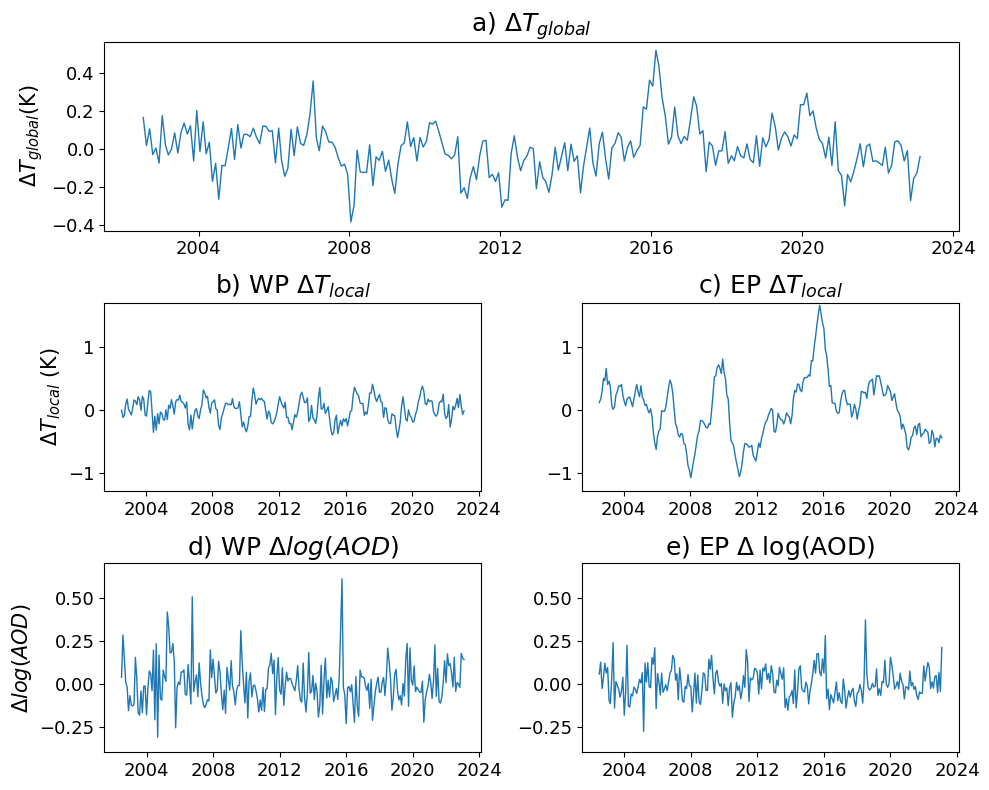

In [31]:
nrows=2
ncols=2

fig = plt.figure(figsize=(5*ncols,4*nrows))
gs = fig.add_gridspec(3, 2)

# First row: span both columns
ax1 = fig.add_subplot(gs[0, :])

# Second row
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# Third row
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

ax1.plot(gmst_np.time, detrend_glob, lw=1.)
ax1.set_title("a) $\Delta T_{global}$")
ax1.set_ylabel(r"$\Delta T_{global}$(K)")


ax2.plot(sst_wp.time, detrend_wp_s, lw=1.)
ax2.set_title(r"b) WP $\Delta T_{local}$")
ax2.set_ylim(-1.3,1.7)
ax2.set_ylabel(r"$\Delta T_{local}$ (K)")


ax3.plot(sst_ep.time, detrend_ep_s, lw=1.)
ax3.set_title(r"c) EP $\Delta T_{local}$")
ax3.set_ylim(-1.3,1.7)
    
ax4.plot(logaodMOD_wp_anom.time, detrend_wp_aod, lw=1.)
ax4.set_title(r"d) WP $\Delta log(AOD)$")
ax4.set_ylim(-0.4,0.7)
ax4.set_ylabel("$\Delta log(AOD)$")


ax5.plot(logaodMOD_ep_anom.time, detrend_ep_aod, lw=1.)
ax5.set_title(r"e) EP $\Delta$ log(AOD)")
ax5.set_ylim(-0.4,0.7)

plt.tight_layout()
#plt.savefig("results/indep_local_vars.jpg")


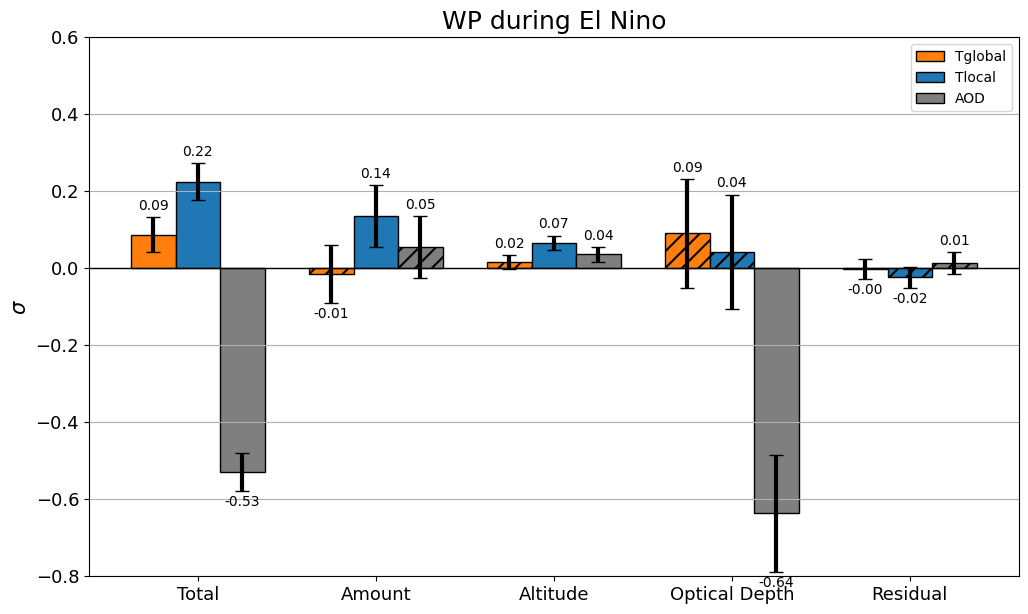

In [101]:
fig, ax = plt.subplots(figsize=(12,7))
plot_net(ax, ds_regress=ml3_wp_nino, feed_gmst=ndecomposet_wp_std_gmst, feed_sst=ndecomposet_wp_std_sst, feed_aods=ndecomposet_wp_std_aod, ylim=[-.8,.6], title="WP during El Nino", unit=r"$\sigma$")
#fig.savefig("barplot_wp.png")

In [103]:
#EP
logX_ep_nino = np.column_stack( (ep_std[0][mask_nino.data].astype(np.float32), ep_std[1][mask_nino.data].astype(np.float32), ep_std[2][mask_nino.data].astype(np.float32)) ) 

In [104]:
ndecomposet_ep_std_gmst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6], time=net_ep.time[mask_nino].data), alllw.sel(lat=itcz, lon=ep, press=[4,5,6], time=net_ep.time[mask_nino].data) ], dates=net_ep.time[mask_nino].values, exog=logX_ep_nino, var=0, p_adj=True)
ndecomposet_ep_std_gmst

ndecomposet_ep_std_sst = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6], time=net_ep.time[mask_nino].data), alllw.sel(lat=itcz, lon=ep, press=[4,5,6], time=net_ep.time[mask_nino].data) ], dates=net_ep.time[mask_nino].values, exog=logX_ep_nino, var=1, p_adj=True)
ndecomposet_ep_std_sst

ndecomposet_ep_std_aod = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6], time=net_ep.time[mask_nino].data), alllw.sel(lat=itcz, lon=ep, press=[4,5,6], time=net_ep.time[mask_nino].data) ], dates=net_ep.time[mask_nino].values, exog=logX_ep_nino, var=2, p_adj=True)
ndecomposet_ep_std_aod

,comp,feed,ci
0,Amt,-0.167842,0.066257
1,Alt,0.008696,0.010566
2,OptD,-0.034338,0.063323
3,Res,-0.006610,0.008322


In [105]:
net_ep_nino = radiative_anomaly(alllw.sel( lat=itcz, lon=ep, time=net_ep.time[mask_nino].data), allsw.sel( lat=itcz, lon=ep, time=net_ep.time[mask_nino].data))
net_ep_nino = detrend(net_ep_nino, ["time", ]) 
ml3_ep_nino = methods.deriv(net_ep_nino, [ep_std[i][mask_nino.data] for i in [0,1,2]])

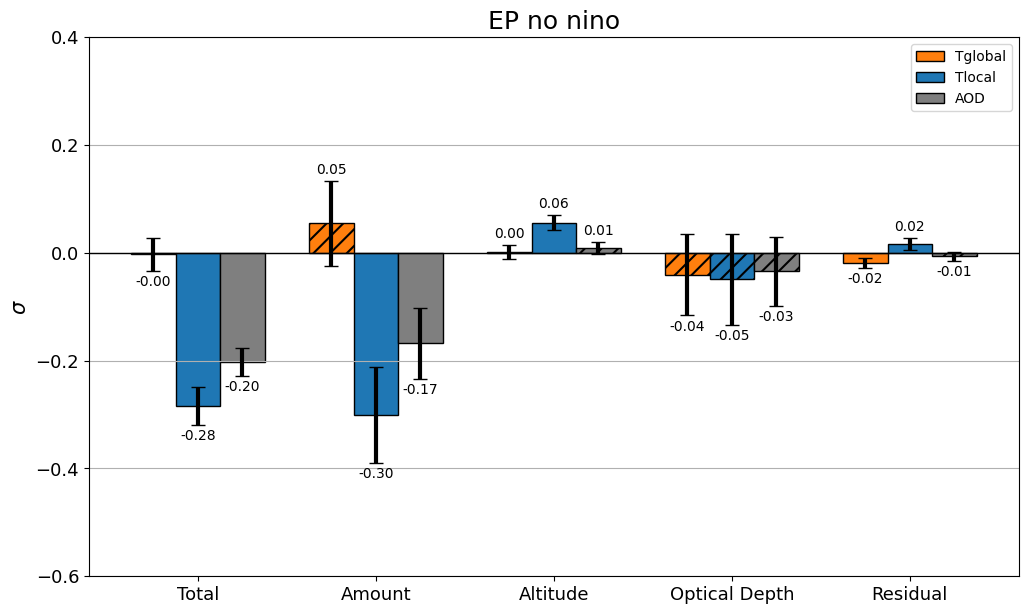

In [107]:
fig, ax = plt.subplots(figsize=(12,7))
plot_net(ax, ds_regress=ml3_ep_nino, feed_gmst=ndecomposet_ep_std_gmst, feed_sst=ndecomposet_ep_std_sst, feed_aods=ndecomposet_ep_std_aod, ylim=[-.6,.4], title="EP no nino", unit=r"$\sigma$")
#fig.savefig("barplot_wp.png")

## MERRA2

In [98]:
import glob
mfiles = glob.glob("../data/MERRA2/*instM*", recursive=True) # Recursively list all files
len(mfiles)

258

In [99]:
# Merra2 AOD
pdir = "../data/MERRA2/"
names = sorted(os.listdir(pdir))

wplist = []
for name in names:
    wplist.append(xa.open_dataset(f"{pdir}{name}", engine='netcdf4').AODANA.sel(lat=itcz, lon=wp))

wpmerra = xa.concat(wplist, dim="time")

eplist = []
for name in names:
    eplist.append(xa.open_dataset(f"{pdir}{name}", engine='netcdf4').AODANA.sel(lat=itcz, lon=slice(-150, -100)))


epmerra = xa.concat(eplist, dim="time")


In [105]:
#WP 
logaodm_wp = xa.apply_ufunc(np.log, area_mean(aodm_wp, "lat", "lon"))
logaodm_wp_anom = logaodm_wp.sel(time = modistime).groupby("time.month") - logaodm_wp.sel(time = modistime).groupby("time.month").mean("time")
detrendm_wp_aod = sm.tsa.tsatools.detrend(logaodm_wp_anom.values)

In [104]:
#EP 
logaodm_ep = xa.apply_ufunc(np.log, area_mean(aodm_ep, "lat", "lon"))
logaodm_ep_anom = logaodm_ep.sel(time = modistime).groupby("time.month") - logaodm_ep.sel(time = modistime).groupby("time.month").mean("time")
detrendm_ep_aod = sm.tsa.tsatools.detrend(logaodm_ep_anom.values)

Showing similarities between MODIS and MERRA2 AOD datasets

array([[1.        , 0.83410785],
       [0.83410785, 1.        ]])

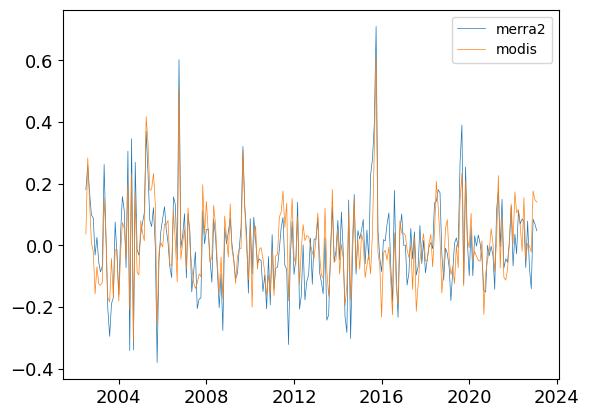

In [107]:
plt.plot(logaodm_wp_anom.time, detrendm_wp_aod, label="merra2", linewidth=0.5)
plt.plot(logaodm_wp_anom.time, detrend_wp_aod,label="modis", linewidth=0.5)
plt.legend()
np.corrcoef(detrend_wp_aod, detrendm_wp_aod)

array([[1.       , 0.8633819],
       [0.8633819, 1.       ]])

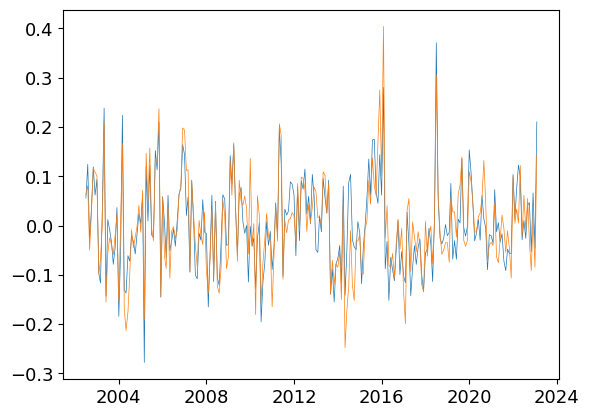

In [106]:
plt.plot(logaodm_ep_anom.time, detrend_ep_aod, linewidth=0.5) 
plt.plot(logaodm_ep_anom.time, detrendm_ep_aod, linewidth=0.5)
np.corrcoef(detrend_ep_aod, detrendm_ep_aod)

Same as Figure 3 in main text but using MERRA-2 as dataset for AOD instead of MODIS

In [112]:
#Independent variables standardised 
ep_std_merra2 = [ (detrend_glob/detrend_glob.std()), (detrend_ep_s/detrend_ep_s.std()), (detrendm_ep_aod/detrendm_ep_aod.std()) ]
wp_std_merra2 = [ (detrend_glob/detrend_glob.std()), (detrend_wp_s/detrend_wp_s.std()), (detrendm_wp_aod/detrendm_wp_aod.std()) ]

#MLR 
cc_ml_ep_m2 = methods.deriv(area_anom_ep, ep_std_merra2) 
cc_ml_wp_m2 = methods.deriv(area_anom_wp, wp_std_merra2) 

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_136/274621023.py:7: SyntaxWarning: invalid escape sequence '\m'
  axs[0,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title="West Pacific \n \n a)$\mathrm{\Theta_{T_{global}}}$",)
/tmp/ipykernel_136/274621023.py:27: SyntaxWarning: invalid escape sequence '\m'
  axs[0,1].set(xlabel=None, ylabel=None, title="East Pacific \n \n b)$\mathrm{\Theta_{T_{global}}}$",)


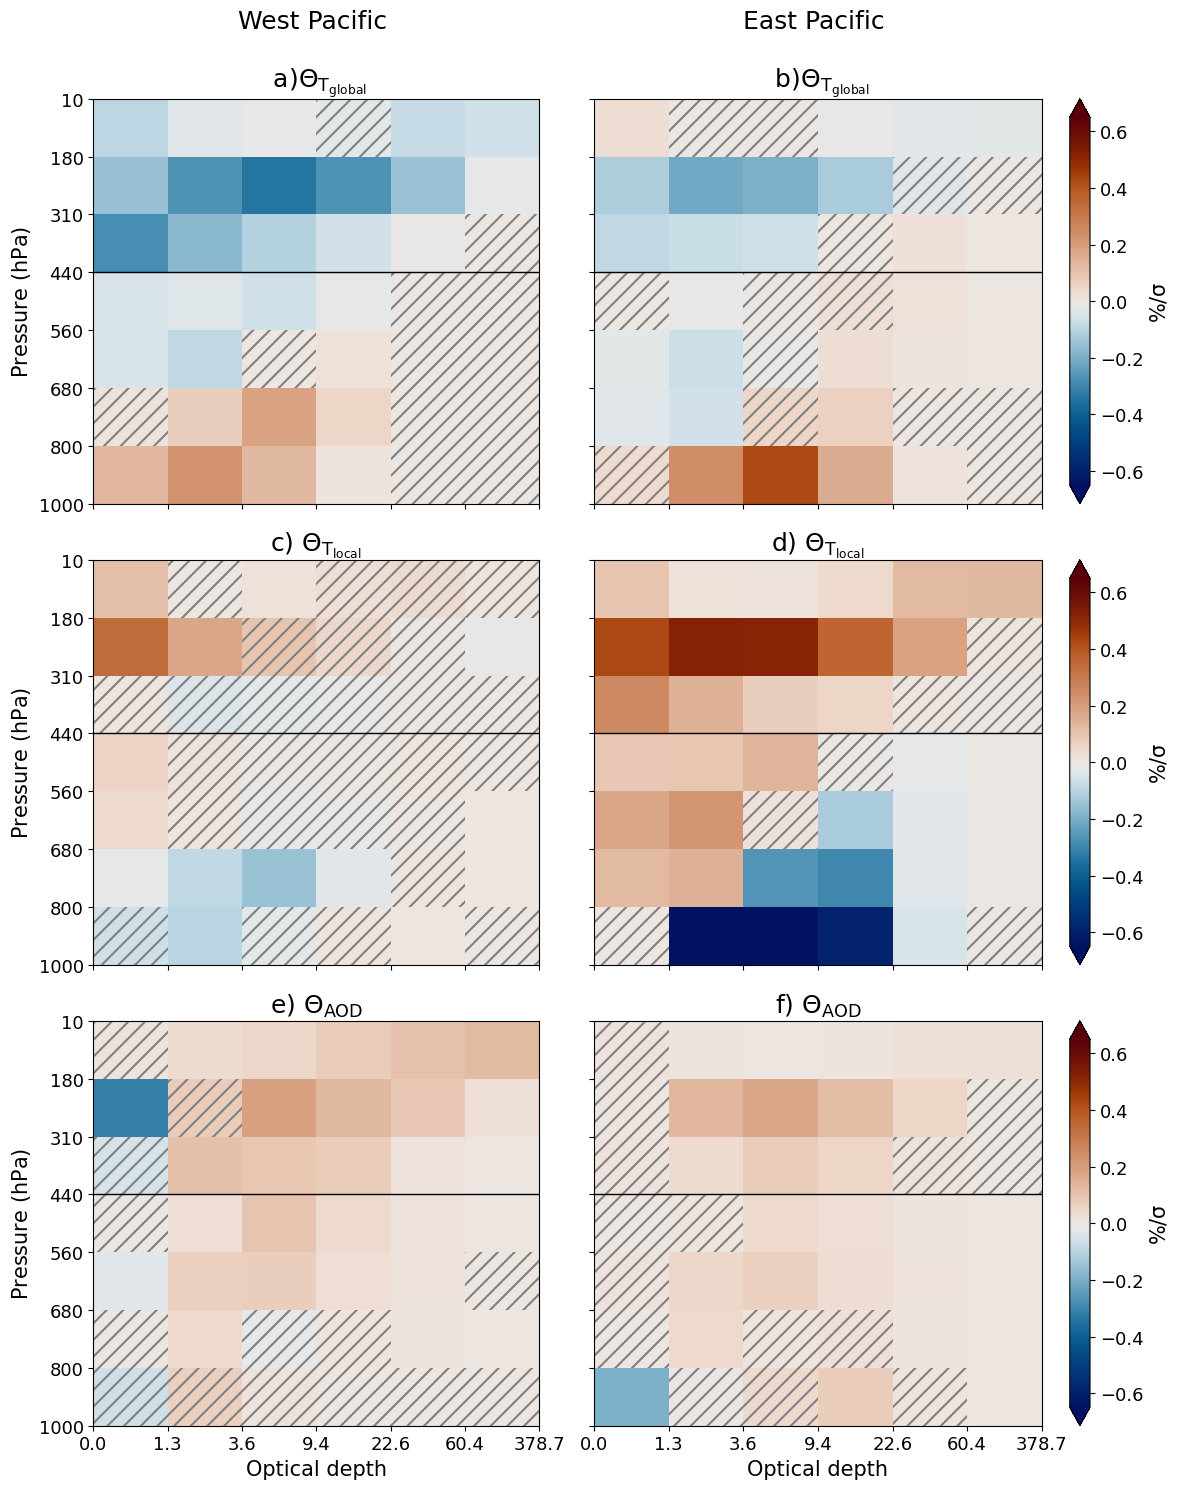

In [113]:
#Fig 3
fig, axs = plt.subplots(3,2,figsize=(12.,15), sharex=True, sharey=True, gridspec_kw={"width_ratios": [0.9, 1.13]})

#WP
var=0
significant_bins(cc_ml_wp_m2, var, 0.05, ax=axs[0,0], vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_wp_m2, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[0,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title="West Pacific \n \n a)$\mathrm{\Theta_{T_{global}}}$",)
axs[0,0].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[0,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=1
significant_bins(cc_ml_wp_m2, var, 0.05, ax=axs[1,0], vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_wp_m2, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[1,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title=r"c) $\mathrm{\Theta_{T_{local}}}$", )
axs[1,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[1,0].set_yticks(np.arange(-0.5,7.5,1), pressure)

var=2
significant_bins(cc_ml_wp_m2, var, 0.05, ax=axs[2,0],vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_wp_m2, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[2,0].set(xlabel="Optical depth", ylabel=r"Pressure $\mathrm{(hPa)}$", title=r"e) $\mathrm{\Theta_{AOD}}$", )
axs[2,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[2,0].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,0].set_yticks(np.arange(-0.5,7.5,1), pressure)

#EP
var=0
significant_bins(cc_ml_ep_m2, var, 0.05, ax=axs[0,1], cbar=True,vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_ep_m2, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[0,1].set(xlabel=None, ylabel=None, title="East Pacific \n \n b)$\mathrm{\Theta_{T_{global}}}$",)
axs[0,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=1
significant_bins(cc_ml_ep_m2, var, 0.05, ax=axs[1,1],cbar=True, vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_ep_m2, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[1,1].set( xlabel=None,ylabel=None, title=r"d) $\mathrm{\Theta_{T_{local}}}$", )
axs[1,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=2
significant_bins(cc_ml_ep_m2, var, 0.05, ax=axs[2,1],cbar=True, vmin=-.65, vmax=.65, values=methods.new_pvals(cc_ml_ep_m2, var, 1), units=r"$\mathrm{\%/\sigma}$")
axs[2,1].set(xlabel="Optical depth", ylabel=None, title=r"f) $\mathrm{\Theta_{AOD}}$", )
axs[2,1].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

plt.tight_layout()

#plt.savefig("results/ccsens_detrend_std_merra2.jpg")

Same as in FIgure 4 but using MERRA-2 as aod

In [119]:
#MLR
ml3_ep_merra2 = methods.deriv(net_ep, ep_std_merra2) 
ml3_wp_merra2 = methods.deriv(net_wp, wp_std_merra2) 

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_136/492846110.py:9: SyntaxWarning: invalid escape sequence '\m'
  axs[0,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title="West Pacific \n \n a) $\mathrm{\Theta_{T_{global}}}$, $\Theta^{hc}_{T_{global}} = 0.10 \pm 0.05$",)
/tmp/ipykernel_136/492846110.py:29: SyntaxWarning: invalid escape sequence '\m'
  axs[0,1].set(xlabel=None, ylabel=None, title="East Pacific \n \n b) $\mathrm{\Theta_{T_{global}}}$, ${\Theta^{hc}}_{T_{global}} = -0.01 \pm 0.03$",)


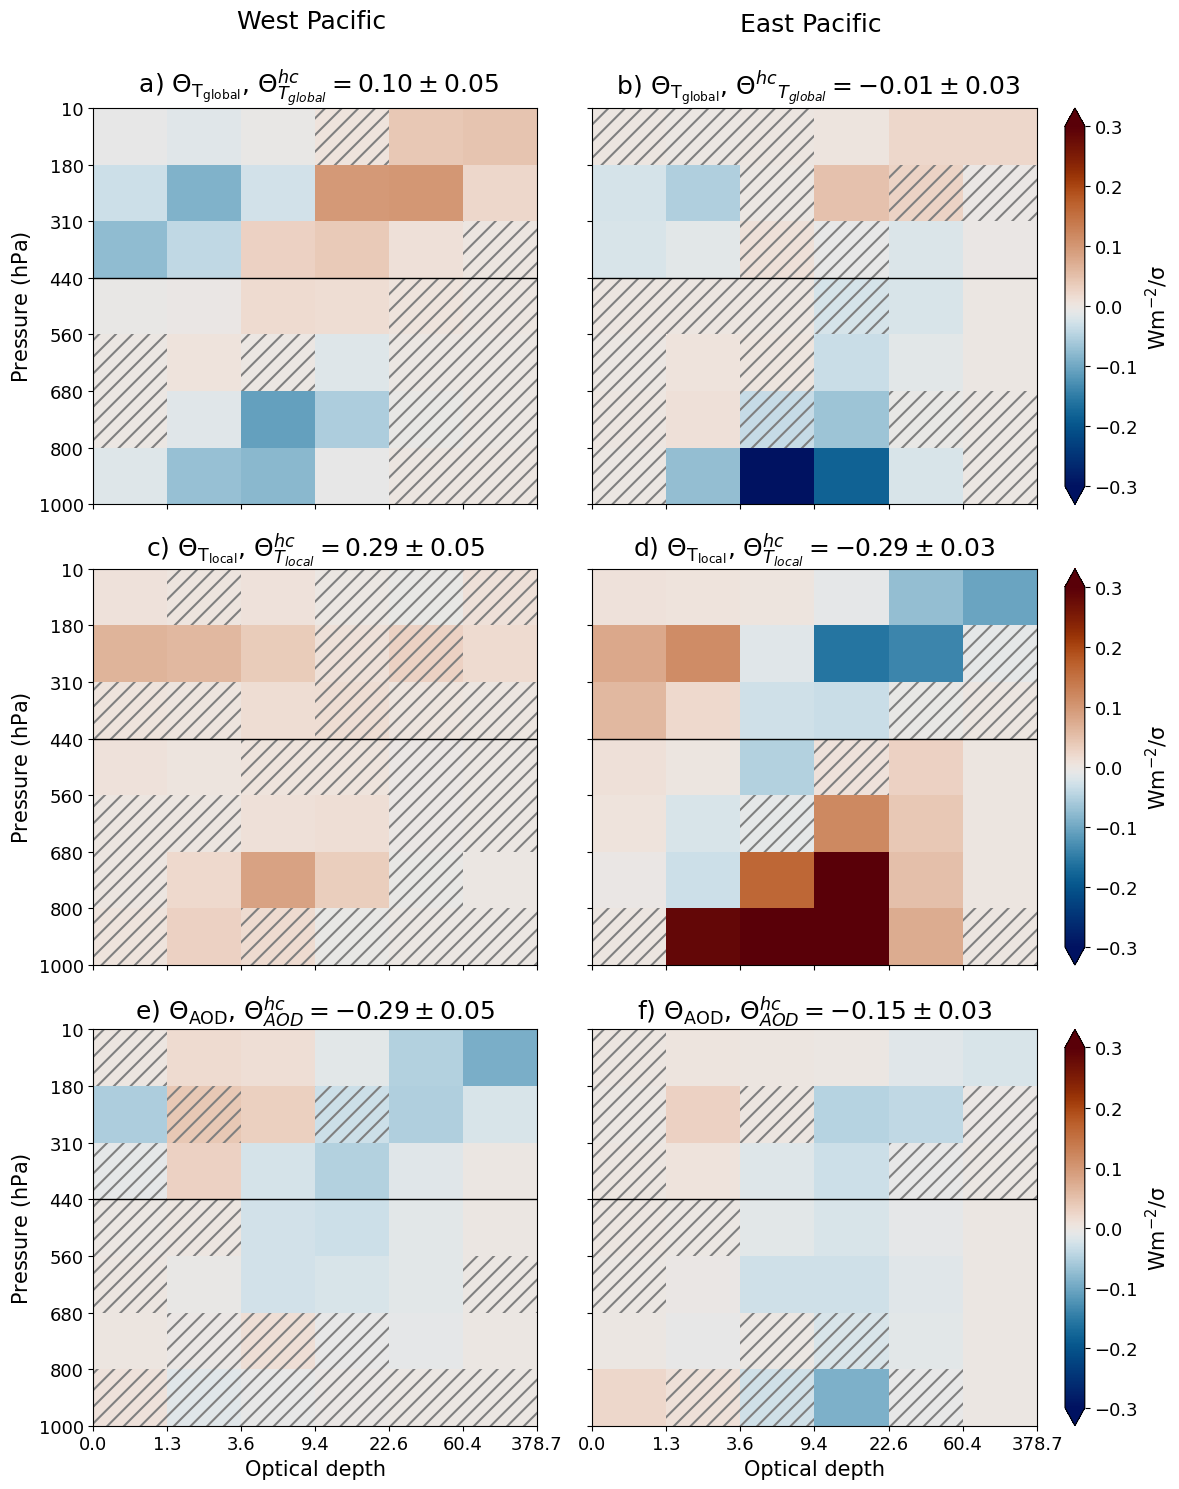

In [134]:
#Figure 4
mn = 0.3

fig, axs = plt.subplots(3,2,figsize=(12.,15), sharex=True, sharey=True, gridspec_kw={"width_ratios": [0.9, 1.13]})
#WP
var=0
significant_bins(ml3_wp_merra2, var, 0.05, ax=axs[0,0], vmin=-mn, vmax=mn, values=methods.new_pvals(ml3_wp_merra2, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[0,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title="West Pacific \n \n a) $\mathrm{\Theta_{T_{global}}}$, $\Theta^{hc}_{T_{global}} = 0.10 \pm 0.05$",)
axs[0,0].set_yticks(np.arange(-0.5,7.5,1), pressure)
axs[0,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=1
significant_bins(ml3_wp_merra2, var, 0.05, ax=axs[1,0], vmin=-mn, vmax=mn, values=methods.new_pvals(ml3_wp_merra2, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[1,0].set(xlabel=None, ylabel=r"Pressure $\mathrm{(hPa)}$", title=r"c) $\mathrm{\Theta_{T_{local}}}$, $\Theta^{hc}_{T_{local}} = 0.29 \pm 0.05$", )
axs[1,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[1,0].set_yticks(np.arange(-0.5,7.5,1), pressure)

var=2
significant_bins(ml3_wp_merra2, var, 0.05, ax=axs[2,0],vmin=-mn, vmax=mn, values=methods.new_pvals(ml3_wp_merra2, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[2,0].set(xlabel="Optical depth", ylabel=r"Pressure $\mathrm{(hPa)}$", title=r"e) $\mathrm{\Theta_{AOD}}$, $\Theta^{hc}_{AOD} = -0.29 \pm 0.05$", )
axs[2,0].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)
axs[2,0].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,0].set_yticks(np.arange(-0.5,7.5,1), pressure)

#EP
var=0
significant_bins(ml3_ep_merra2, var, 0.05, ax=axs[0,1], cbar=True,vmin=-mn, vmax=mn, values=methods.new_pvals(ml3_ep_merra2, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[0,1].set(xlabel=None, ylabel=None, title="East Pacific \n \n b) $\mathrm{\Theta_{T_{global}}}$, ${\Theta^{hc}}_{T_{global}} = -0.01 \pm 0.03$",)
axs[0,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=1
significant_bins(ml3_ep_merra2, var, 0.05, ax=axs[1,1],cbar=True, vmin=-mn, vmax=mn, values=methods.new_pvals(ml3_ep_merra2, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[1,1].set( xlabel=None,ylabel=None, title=r"d) $\mathrm{\Theta_{T_{local}}}$, $\Theta^{hc}_{T_{local}} = -0.29 \pm 0.03$", )
axs[1,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

var=2
significant_bins(ml3_ep_merra2, var, 0.05, ax=axs[2,1],cbar=True, vmin=-mn, vmax=mn, values=methods.new_pvals(ml3_ep_merra2, var, 1), units=r"$\mathrm{Wm^{-2}/\sigma}$")
axs[2,1].set(xlabel="Optical depth", ylabel=None, title=r"f) $\mathrm{\Theta_{AOD}}$, $\Theta^{hc}_{AOD} = -0.15 \pm 0.03$", )
axs[2,1].set_xticks(np.arange(-0.5,6.5,1), optical_dept)
axs[2,1].axhline(y=3.5, xmin=0, xmax=6, c="k", lw=1.)

plt.tight_layout()

#plt.savefig("results/cresens_std_merra2.jpg")

COmputing totals (shown on top)

In [127]:
total_hc(ml3_ep_merra2, var=0) 

(-0.012230910557681936, 0.03111192171768202)

In [128]:
total_hc(ml3_ep_merra2, var=1) 

(-0.2872737516109109, 0.030706107028243355)

In [129]:
total_hc(ml3_ep_merra2, var=2) 

(-0.14910824072784662, 0.02673696050004449)

In [130]:
total_hc(ml3_wp_merra2, var=0) 

(0.09766967554374359, 0.0471471572724246)

In [131]:
total_hc(ml3_wp_merra2, var=1) 

(0.28759325283920856, 0.04946613654501799)

In [132]:
total_hc(ml3_wp_merra2, var=2) 

(-0.28771275072221414, 0.04915970301434342)

Decomposition: 

Same as Figure 5 in main but using MERRA2 for AOD

EP

In [136]:
#independent variables
logX_ep_merra2 = np.column_stack( (ep_std_merra2[0].astype(np.float32), ep_std_merra2[1].astype(np.float32), ep_std_merra2[2].astype(np.float32)) ) 

In [137]:
decomposet_ep_std_gmst_merra2 = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6]), alllw.sel(lat=itcz, lon=ep, press=[4,5,6])], dates=modistime, exog=logX_ep_merra2, var=0, p_adj=True)
decomposet_ep_std_gmst_merra2 

,comp,feed,ci
0,Amt,0.049987,0.081503
1,Alt,-0.001878,0.012031
2,OptD,-0.041660,0.072805
3,Res,-0.018944,0.010054


In [138]:
decomposet_ep_std_sst_merra2 = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6]), alllw.sel(lat=itcz, lon=ep, press=[4,5,6])], dates=modistime, exog=logX_ep_merra2, var=1, p_adj=True)
decomposet_ep_std_sst_merra2

,comp,feed,ci
0,Amt,-0.405126,0.080439
1,Alt,0.058498,0.011874
2,OptD,0.037779,0.071855
3,Res,0.017067,0.009923


In [139]:
decomposet_ep_std_aod_merra2 = decompos_hc("net", [ allsw.sel(lat=itcz, lon=ep, press=[4,5,6]), alllw.sel(lat=itcz, lon=ep, press=[4,5,6])], dates=modistime, exog=logX_ep_merra2, var=2, p_adj=True)
decomposet_ep_std_aod_merra2

,comp,feed,ci
0,Amt,-0.141601,0.070042
1,Alt,0.007659,0.010339
2,OptD,-0.011165,0.062567
3,Res,-0.004384,0.008640


WP

In [140]:
logX_wp_merra2 = np.column_stack( (wp_std_merra2[0].astype(np.float32), wp_std_merra2[1].astype(np.float32), wp_std_merra2[2].astype(np.float32)) ) 

In [141]:

decomposet_wp_std_gmst_merra2 = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6])], dates=modistime, exog=logX_wp_merra2, var=0, p_adj=True)
decomposet_wp_std_gmst_merra2

,comp,feed,ci
0,Amt,-0.114682,0.074484
1,Alt,0.008396,0.016912
2,OptD,0.234102,0.141018
3,Res,-0.029025,0.024669


In [142]:

decomposet_wp_std_sst_merra2 = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6])], dates=modistime, exog=logX_wp_merra2, var=1, p_adj=True)
decomposet_wp_std_sst_merra2

,comp,feed,ci
0,Amt,0.171222,0.078148
1,Alt,0.064828,0.017744
2,OptD,0.061632,0.147954
3,Res,-0.010804,0.025882


In [143]:

decomposet_wp_std_aod_merra2 = decompos_hc("net", [ allsw.sel(lat=itcz, lon=wp, press=[4,5,6]), alllw.sel(lat=itcz, lon=wp, press=[4,5,6])], dates=modistime, exog=logX_wp_merra2, var=2, p_adj=True)
decomposet_wp_std_aod_merra2

,comp,feed,ci
0,Amt,0.123001,0.077664
1,Alt,0.020529,0.017634
2,OptD,-0.445119,0.147038
3,Res,0.013601,0.025722


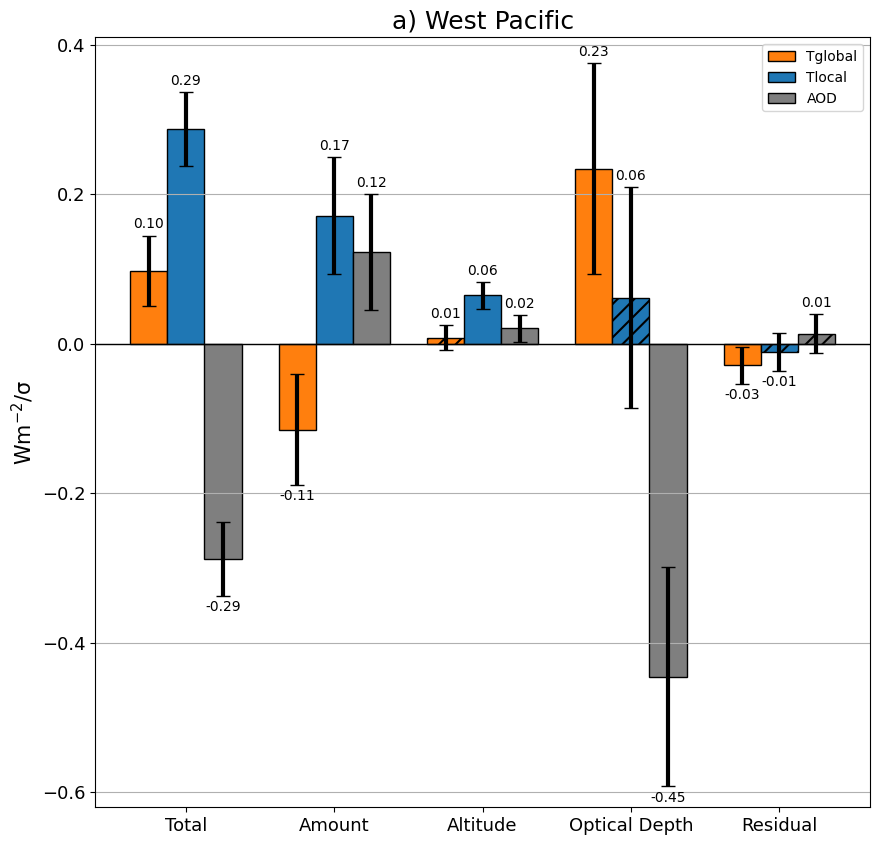

In [149]:
#WP
fig, ax1 = plt.subplots(1,1,figsize=(10,10),) # gridspec_kw={"width_ratios": [0.85, 0.85, 1]

#fig, ax = plt.subplots(figsize=(10,6))
p1 = plot_net(ax=ax1, ds_regress= ml3_wp_merra2, 
              feed_gmst=decomposet_wp_std_gmst_merra2, feed_sst=decomposet_wp_std_sst_merra2, feed_aods=decomposet_wp_std_aod_merra2, 
              title="a) West Pacific", ylim=[-.62,.41], unit=r"$\mathrm{Wm^{-2}/\sigma}$")

plt.show()
fig.tight_layout()
fig.savefig("barsplot_wp_merra2.png")

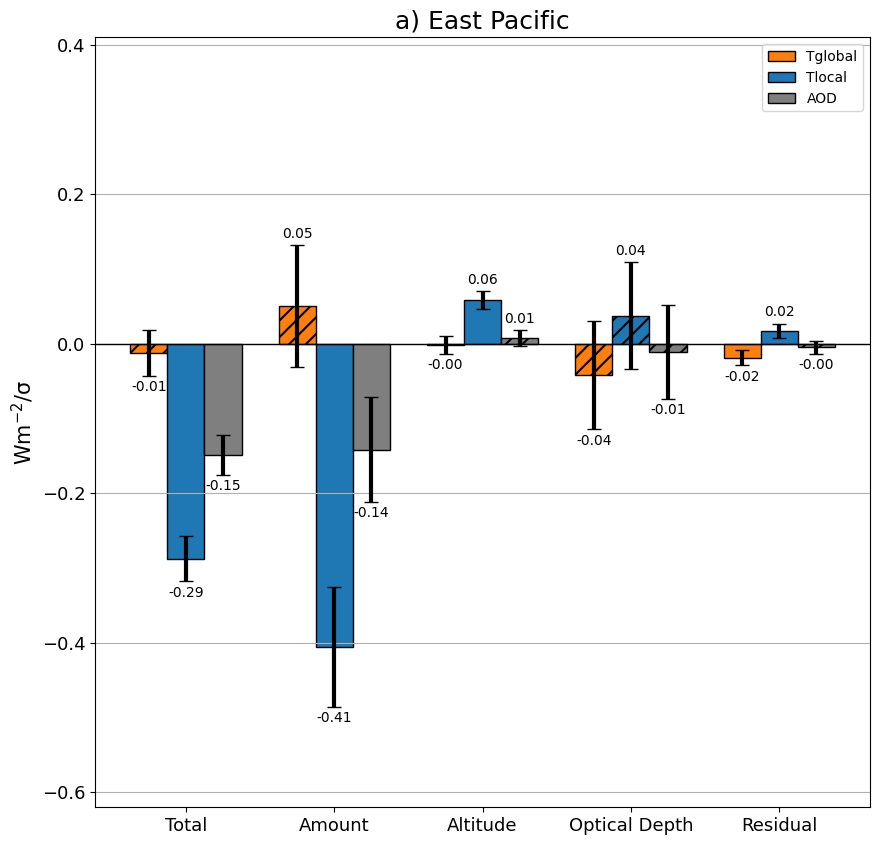

In [150]:
#WP
fig, ax1 = plt.subplots(1,1,figsize=(10,10),) # gridspec_kw={"width_ratios": [0.85, 0.85, 1]

#fig, ax = plt.subplots(figsize=(10,6))
p1 = plot_net(ax=ax1, ds_regress=ml3_ep_merra2, 
              feed_gmst=decomposet_ep_std_gmst_merra2, feed_sst=decomposet_ep_std_sst_merra2, feed_aods=decomposet_ep_std_aod_merra2, 
              title="a) East Pacific", ylim=[-.62,.41], unit=r"$\mathrm{Wm^{-2}/\sigma}$")

plt.show()
fig.tight_layout()
fig.savefig("barsplot_ep_.png")